<div style="display: flex; align-items: center; justify-content: space-between">
    <div>
        <img src="https://raw.githubusercontent.com/sebastianVP/RADAR_AMISR/refs/heads/main/igp_logo.jpeg"
         alt="LOGO IGP" width="200" height="200" style="margin-left: 20px; border-radius: 10px;" align = "right">
        <h1 style="color: #800020;  font-weight: bold; margin-bottom: 10px; font-family: Arial, sans-serif;">
          <font color="#7F000E">
            Maestría de Ciencias de la Computación UNI-IGP
          </font>
        </h1>
        <h2 style="color: #800020;font-weight: bold; max-width: 750px; font-family: Arial, sans-serif;">
          <strong><font color="#7F000E" size=5 >
            Desarrollo de sistema de pronóstico de centelleo ionosférico sobre el Perú para alerta de
            perturbaciones en señales satelitales
          </font ></strong>
        </h2>
    </div>
</div>
<div>
    <p style="margin-bottom: 5px;">
    <strong>
    <font color="#7F000E" size=4 > OBSERVACIONES Y MEJORAS DE TESIS</strong></p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Alumno:</strong></font>
    <font color="#7F000E"> Alexander Valdez Portocarrero</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Código:</strong> 20207072E</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Fecha:</strong>  12/08/2026 - UPDATE FINAL</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong> Ciclo 2026</strong></p>
</div>

---

# **PASO 0: Mapa general de todas las observaciones:**
Tenemos dos fuentes:

**Dr. Yuri**

Observaciones generales y apuntan principalmente a:

1. Buscar empresas potencialmente interesadas/compradoras.
2. Sustentar que las pruebas realizadas son las mejores.
3. Fortalecer la bibliografía sobre series de tiempo y LSTM.
4. Organizar y consolidar la bibliografía.
5. Construir una línea de tiempo.
6. Sustentar por qué se utiliza LSTM.
7. Sustentar matemáticamente la interpolación.
8. Precisar tipo de datos.
9. Precisar modelo.
10. Precisar análisis de datos.
11. Sustentar bibliográficamente la resolución.
12. Incorporar anexo de resultados.
13. Incorporar tablas comparativas de pruebas de modelos y variaciones de parámetros.

**Dr. Marcos Alania**

Observaciones  específicas y metodológicamente críticas:

1. Data leakage / fuga de información.
2. Cambiar a validación Out-of-Time.
3. Actualizar estado del arte 2022–2026.
4. Incorporar al menos un Transformer para series temporales.
5. Incorporar modelo de persistencia.
6. Realizar ablation studies.
7. Justificar α = 2 y β = 50.
8. Analizar falsas alarmas.
9. Demostrar qué ocurre con ROTI y S4.
10. Incorporar Feature Importance o saliency.
11. Incorporar pruebas estadísticas.
12. Revisar inconsistencias temporales.
13. Comparar latencia y Recall.
14. Justificar la elección final de LSTM frente a Transformer.


# **PASO1. RESOLVER EL DATA LEAKAGE**

El Dr. Marcos detectó que en la tesis se menciona un **“muestreo estratificado”** para generar el Test Set, algo peligroso en forecasting temporal porque puede mezclar información del futuro con el pasado.

Esto es lo primero que debemos revisar.

# Preparación temporal rigurosa de datos para pronóstico LSTM de S4

**Tesis de Maestría en Ciencias de la Computación UNI–IGP**

Esta versión reemplaza la partición estratificada aleatoria del notebook original por una estrategia estrictamente cronológica.

### Principios metodológicos

1. La serie se ordena cronológicamente antes de cualquier partición.
2. No se eliminan días sin eventos.
3. Los eventos se identifican como intervalos independientes, no como minutos individuales.
4. Train < Validation < Test.
5. Las ventanas se generan después de la partición y por separado.
6. Los gaps impiden generar ventanas que crucen discontinuidades.
7. El scaler se ajusta exclusivamente con Train.
8. Las variables temporales cíclicas se calculan a partir del timestamp.
9. No se utiliza `train_test_split`, oversampling, undersampling ni SMOTE.
10. Todas las decisiones de partición quedan auditadas y reportadas.

El notebook está preparado para trabajar con un DataFrame existente llamado `df`, cuyo índice sea `DatetimeIndex` y cuya variable objetivo sea `S4`.


## Estrategia de partición

Se utiliza inicialmente una partición cronológica cercana a **70/15/15**, pero no se fuerza ese porcentaje cuando produce una representación claramente insuficiente de eventos.

La función `find_temporal_split()` evalúa cortes **por día** y prioriza, en este orden:

**integridad temporal → ausencia de leakage → presencia de eventos → cercanía a 70/15/15**.

Los meses sin eventos permanecen en la serie y se reportan explícitamente. No se redistribuyen aleatoriamente.

Esta estrategia es apropiada para forecasting porque Validation y Test representan información posterior a Train, aproximando una evaluación **Out-of-Time**. En un fenómeno raro, una partición perfectamente balanceada puede no existir; en ese caso se conserva la causalidad temporal y se documenta la desigualdad.

> Importante: la selección automática de cortes utiliza el diagnóstico de eventos del dataset completo únicamente para escoger límites cronológicos antes del entrenamiento. No utiliza información de Validation/Test para ajustar el scaler, entrenar el modelo ni crear ventanas de Train.


## ETAPA I
## Secuencia:
```text
    1. Cargar dataset
            ↓
    3. Orden temporal
            ↓
    4. Identificación de eventos
            ↓
    5. Análisis mensual
            ↓
    6. Selección de corte temporal
            ↓
    7. create_temporal_split()
            ↓
    8. validate_temporal_split()
            ↓
    9. VISUALIZACIÓN TEMPORAL  ← aquí
            ↓
    10. add_temporal_features()
            ↓
    11. create_scaler()
            ↓
    12. scale_partitions()
            

In [30]:
# =============================================================================
# 1. CONFIGURACIÓN
# =============================================================================

import os
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler

warnings.filterwarnings("ignore")

# -----------------------------
# Parámetros principales
# -----------------------------
TARGET_COL = "S4"

# El criterio científico Utilizado es S4 mayor o igual a 0.6 plasmado en la metodología de la tesis.
S4_EVENT_THRESHOLD = 0.6

# Si son None, NO se impone una duración científica que no haya sido definida.
MIN_EVENT_DURATION = None          # minutos
MAX_GAP_BETWEEN_EVENTS = None      # minutos

LOOKBACK = 70
HORIZON = 10                        # cambiar a 15 para el segundo experimento

SAMPLING_MINUTES = 1
# TENTATIVOS
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Número mínimo deseado de eventos por partición.
# No se fuerza artificialmente si la serie no lo permite.
MIN_EVENTS_TRAIN = 1
MIN_EVENTS_VAL   = 1
MIN_EVENTS_TEST  = 1

# Scaler configurable: "minmax" o "standard"
SCALER_TYPE = "minmax"

# Si True, se evalúan cortes diarios alternativos buscando una mejor
# representación de eventos sin romper la cronología.
SEARCH_EVENT_AWARE_SPLIT = True

# Variables candidatas al modelo.
# S4 se mantiene como predictor histórico y como variable objetivo futura.
FEATURES_COLS = ["TEC","ROTI","Kp_Index","Dst_Index","AE_Index","f10.7_Index","daily_sin","daily_cos","day_of_year_sin","day_of_year_cos","S4"]

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9

print("Configuración cargada.")
print(f"Umbral de evento S4 >= {S4_EVENT_THRESHOLD}")
print(f"LOOKBACK = {LOOKBACK} min | HORIZON = {HORIZON} min")
print(f"Sampling esperado = {SAMPLING_MINUTES} min")


Configuración cargada.
Umbral de evento S4 >= 0.6
LOOKBACK = 70 min | HORIZON = 10 min
Sampling esperado = 1 min


In [32]:
# =====================================================================
# 0. CARGAR DATASET
# =====================================================================
def cargar_dataset(path, filename):
    """
    Carga el CSV y realiza la conversión inicial de fechas.
    """
    full_path = os.path.join(path, filename)

    if not os.path.exists(full_path):
        raise FileNotFoundError(f"No se encontró el archivo en: {full_path}")

    print(f"📂 Cargando archivo: {filename}...")
    df = pd.read_csv(full_path)

    # Conversión única y definitiva a datetime
    df["Tiempo"] = pd.to_datetime(df["Tiempo"])

    # Ordenar cronológicamente (vital para series temporales)
    df = df.sort_values("Tiempo")

    print(f"✅ Dataset cargado. Shape: {df.shape}")
    print(f"   Rango de fechas: {df['Tiempo'].min()} a {df['Tiempo'].max()}")
    return df

# =====================================================================
# 1. CONVERSION DE COLUMAN TEMPORAL A DATETIME 
# =====================================================================

def sort_temporally(df, time_col="Tiempo"):
    """
    Convierte la columna temporal a datetime,
    establece Tiempo como índice y ordena cronológicamente.
    """

    out = df.copy()

    # ---------------------------------------------------------
    # 1. Verificar que exista la columna temporal
    # ---------------------------------------------------------
    if time_col not in out.columns:
        raise ValueError(f"No existe la columna temporal '{time_col}'.")

    # ---------------------------------------------------------
    # 2. Convertir la columna Tiempo a datetime
    # ---------------------------------------------------------
    out[time_col] = pd.to_datetime(out[time_col],errors="coerce")

    # ---------------------------------------------------------
    # 3. Detectar fechas que no pudieron convertirse
    # ---------------------------------------------------------
    n_invalid = out[time_col].isna().sum()

    if n_invalid > 0:
        raise ValueError(
            f"Se encontraron {n_invalid:,} valores inválidos "
            f"en la columna '{time_col}'."
        )

    # ---------------------------------------------------------
    # 4. Establecer Tiempo como índice
    # ---------------------------------------------------------
    out = out.set_index(time_col)

    # ---------------------------------------------------------
    # 5. Ordenar cronológicamente
    # ---------------------------------------------------------
    out = out.sort_index()

    # ---------------------------------------------------------
    # 6. Mostrar información de control
    # ---------------------------------------------------------
    print("=" * 80)
    print("ORDENAMIENTO TEMPORAL")
    print("=" * 80)
    print(f"Tipo de índice:     {type(out.index).__name__}")
    print(f"Fecha mínima:       {out.index.min()}")
    print(f"Fecha máxima:       {out.index.max()}")
    print(f"Observaciones:      {len(out):,}")
    print("=" * 80)

    return out
# =============================================================================
# 2. VALIDACIÓN DEL DATASET
# =============================================================================

def validate_dataframe(df, target_col=TARGET_COL):
    """Valida estructura mínima y calidad básica del DataFrame."""

    if not isinstance(df, pd.DataFrame):
        raise TypeError("df debe ser un pandas.DataFrame.")

    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError(
            "El índice de df debe ser un pandas.DatetimeIndex. "
            "Use df['Tiempo'] y luego df.set_index('Tiempo') si es necesario."
        )

    if target_col not in df.columns:
        raise ValueError(f"No existe la columna objetivo '{target_col}'.")

    if df.empty:
        raise ValueError("El DataFrame está vacío.")

    if df.index.has_duplicates:
        dup = int(df.index.duplicated().sum())
        raise ValueError(f"El índice contiene {dup} timestamps duplicados. ""Deben resolverse antes de crear ventanas."
        )

    if not pd.api.types.is_numeric_dtype(df[target_col]):
        raise TypeError(f"{target_col} debe ser numérica.")

    if df[target_col].isna().any():
        n = int(df[target_col].isna().sum())
        raise ValueError(
            f"S4 contiene {n} valores NaN. "
            "No se deben generar ventanas sobre observaciones objetivo faltantes."
        )

    if not np.isfinite(df[target_col].to_numpy(dtype=float)).all():
        raise ValueError("S4 contiene valores infinitos o no finitos.")

    if not df.index.is_monotonic_increasing:
        print("ADVERTENCIA: el índice no está ordenado. Se ordenará.")

    print("=" * 80)
    print("VALIDACIÓN DEL DATASET")
    print("=" * 80)
    print(f"Filas:              {len(df):,}")
    print(f"Columnas:           {len(df.columns)}")
    print(f"Fecha mínima:       {df.index.min()}")
    print(f"Fecha máxima:       {df.index.max()}")
    print(f"Días calendario:    {df.index.normalize().nunique():,}")
    print(f"Meses calendario:   {df.index.to_period('M').nunique():,}")
    print(f"S4 mínimo:          {df[target_col].min():.6f}")
    print(f"S4 máximo:          {df[target_col].max():.6f}")
    print("=" * 80)

    return True

# =============================================================================
#  EJECUCIÓN DEL PIPELINE (MAIN)
# =============================================================================
if __name__ == "__main__":
    

#1. Configuracion
    N_ESTACION = 0 # Escoge la estación
    ESTACION    = ["JICAMARCA","HUANCAYO","PIURA","CUZCO","PUCALLPA","AYACUCHO","TACNA","IQUITOS"]
    RUTA        = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
    ARCHIVO     = f"DF_FINAL_{ESTACION[N_ESTACION]}_{31072026}.csv"
    print("="*60)
    #print(f"RUTA DRIVE: {RUTA_DRIVE}")
    print(f"RUTA : {RUTA}")
    print(f"Trabajamos con el archivo: {ARCHIVO}")
    print("="*60)
    # Definición de Features para el modelo (Orden Importante)
    
    FEATURES_COLS = ["TEC","ROTI","Kp_Index","Dst_Index","AE_Index","f10.7_Index","daily_sin","daily_cos","day_of_year_sin","day_of_year_cos","S4"]
    
    # ============================================================
    # 2. Pipeline de ejecución
    # ============================================================
    
    # ------------------------------------------------------------
    # Cargar dataset
    # ------------------------------------------------------------
    df = cargar_dataset(RUTA, ARCHIVO)
    
    print(df.head())
    
    # ------------------------------------------------------------
    # Ordenar y establecer Tiempo como índice
    # ------------------------------------------------------------
    df = sort_temporally(df,time_col="Tiempo")
    
    # ------------------------------------------------------------
    # Validar dataset
    # ------------------------------------------------------------
    validate_dataframe(df)
    
    print("Dataset listo para el procesamiento temporal.")


RUTA : /home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook
Trabajamos con el archivo: DF_FINAL_JICAMARCA_31072026.csv
📂 Cargando archivo: DF_FINAL_JICAMARCA_31072026.csv...
✅ Dataset cargado. Shape: (696090, 14)
   Rango de fechas: 2025-01-26 00:35:00 a 2026-07-21 22:45:00
               Tiempo  ID_Satelite  Azimuth  Elevacion   Estacion        TEC  \
0 2025-01-26 00:35:00         39.0    189.0       31.0  JICAMARCA  70.689140   
1 2025-01-26 00:36:00         39.0    189.0       32.0  JICAMARCA  70.778647   
2 2025-01-26 00:37:00         13.0    197.0       32.0  JICAMARCA  70.868153   
3 2025-01-26 00:38:00         39.0    189.0       33.0  JICAMARCA  70.957660   
4 2025-01-26 00:39:00         13.0    196.0       32.0  JICAMARCA  71.047166   

      ROTEC      ROTI  Kp_Index  Dst_Index  ap_Index  f10.7_Index   AE_Index  \
0 -0.012351  0.010958       3.0  -1.416667       2.0        165.4  29.083333   
1 -0.010967  0.010961       3.0  -1.400000       2.0        165.4  29.000

In [33]:
# =============================================================================
# 3. CALIDAD TEMPORAL: GAPS Y DÍAS INCOMPLETOS
# =============================================================================

def validate_gaps(df, expected_minutes=SAMPLING_MINUTES):
    """Detecta gaps y resume calidad temporal sin asumir 1440 filas por día."""

    idx = pd.DatetimeIndex(df.index)
    delta = idx.to_series().diff()

    gaps = delta[delta > pd.Timedelta(minutes=expected_minutes)]
    duplicates = delta[delta == pd.Timedelta(0)]

    daily = pd.DataFrame(index=idx)
    daily["date"] = idx.normalize()

    daily_summary = (daily.groupby("date").size().rename("observations").to_frame()
    )

    daily_summary["complete_1440"] = daily_summary["observations"] == 1440
    daily_summary["incomplete"] = daily_summary["observations"] < 1440

    # Un día puede tener >1440 observaciones en datasets con duplicados,
    # aunque los duplicados ya se auditan antes.
    daily_summary["has_gap"] = False

    for date, group in pd.Series(idx, index=idx).groupby(idx.normalize()):
        d = group.sort_values().diff()
        if (d > pd.Timedelta(minutes=expected_minutes)).any():
            daily_summary.loc[date, "has_gap"] = True

    gap_report = pd.DataFrame({
        "gap_start": gaps.index[:-0] if False else gaps.index,
        "gap_duration": gaps.values
    })

    print("\n" + "=" * 80)
    print("REPORTE DE CALIDAD TEMPORAL")
    print("=" * 80)
    print(f"Observaciones:                  {len(idx):,}")
    print(f"Intervalos > {expected_minutes} min:       {len(gaps):,}")
    print(f"Intervalos duplicados:           {len(duplicates):,}")
    print(f"Días registrados:                {len(daily_summary):,}")
    print(f"Días con 1440 observaciones:     {daily_summary['complete_1440'].sum():,}")
    print(f"Días con <1440 observaciones:    {daily_summary['incomplete'].sum():,}")
    print(f"Días con gaps:                   {daily_summary['has_gap'].sum():,}")

    if len(gaps):
        print("\nPrimeros gaps:")
        print(gap_report.head(10))

    return {
        "gaps": gap_report,
        "daily_quality": daily_summary,
    }


quality_report = validate_gaps(df)



REPORTE DE CALIDAD TEMPORAL
Observaciones:                  696,090
Intervalos > 1 min:       558
Intervalos duplicados:           0
Días registrados:                512
Días con 1440 observaciones:     0
Días con <1440 observaciones:    512
Días con gaps:                   33

Primeros gaps:
            gap_start    gap_duration
0 2025-01-27 00:01:00 0 days 00:16:00
1 2025-01-28 00:01:00 0 days 00:16:00
2 2025-01-28 15:23:00 0 days 00:10:00
3 2025-01-28 15:51:00 0 days 00:16:00
4 2025-01-28 18:44:00 0 days 00:04:00
5 2025-01-29 00:01:00 0 days 00:16:00
6 2025-01-30 00:01:00 0 days 00:16:00
7 2025-01-31 00:01:00 0 days 00:16:00
8 2025-02-01 00:01:00 0 days 00:16:00
9 2025-02-02 00:01:00 0 days 00:16:00


In [35]:
# =============================================================================
# 4. IDENTIFICACIÓN DE EVENTOS INDEPENDIENTES
# =============================================================================

def identify_events(
    df,
    target_col=TARGET_COL,
    threshold=S4_EVENT_THRESHOLD,
    min_duration=MIN_EVENT_DURATION,
    max_gap_between_events=MAX_GAP_BETWEEN_EVENTS,
    expected_minutes=SAMPLING_MINUTES,
):
    """
    Identifica eventos independientes de S4.

    - Evento básico: S4 >= threshold.
    - Un gap de adquisición (timestamp consecutivo > expected_minutes)
      SIEMPRE rompe un evento.
    - Si max_gap_between_events no es None, permite unir dos tramos activos
      separados por observaciones existentes por debajo del umbral, siempre
      que no exista un gap de adquisición y la separación sea <= max_gap.
    - min_duration es opcional y no se inventa científicamente.
    """

    s = df[target_col].astype(float)
    idx = pd.DatetimeIndex(df.index)
    active = (s >= threshold).to_numpy()

    # Si no hay observaciones activas, devolver tabla vacía.
    if not active.any():
        return pd.DataFrame(
            columns=["event_id", "start", "end", "duration_min","n_observations", "max_S4", "date", "month"]
        )

    # Primero se construyen tramos consecutivos de estado activo/inactivo.
    state_change = np.r_[True, active[1:] != active[:-1]]

    run_id = np.cumsum(state_change) - 1
    runs = []

    for rid in np.unique(run_id[active]):
        pos = np.flatnonzero(run_id == rid)
        if len(pos) == 0:
            continue

        runs.append({"start_pos": int(pos[0]),"end_pos": int(pos[-1]),"start": idx[pos[0]],"end": idx[pos[-1]],"n_observations": len(pos),"max_S4": float(s.iloc[pos].max()),})

    if not runs:
        return pd.DataFrame(columns=["event_id", "start", "end", "duration_min","n_observations", "max_S4", "date", "month"])

    # Fusionar tramos activos separados por un pequeño intervalo por debajo
    # del umbral, pero nunca atravesar un gap de adquisición.
    merged = []
    current = runs[0].copy()

    for nxt in runs[1:]:
        # Todas las filas entre ambos tramos deben existir con resolución
        # temporal esperada; si no, hay un gap real de adquisición.
        between = idx[current["end_pos"]:nxt["start_pos"] + 1]
        deltas = pd.Series(between).diff().dropna()

        acquisition_gap = (
            len(deltas) > 0 and
            (deltas > pd.Timedelta(minutes=expected_minutes)).any()
        )

        separation_min = (
            nxt["start"] - current["end"]
        ).total_seconds() / 60.0

        can_merge = (
            max_gap_between_events is not None
            and not acquisition_gap
            and separation_min <= max_gap_between_events
        )

        if can_merge:
            current["end_pos"] = nxt["end_pos"]
            current["end"] = nxt["end"]
            current["n_observations"] += nxt["n_observations"]
            current["max_S4"] = max(current["max_S4"], nxt["max_S4"])
        else:
            merged.append(current)
            current = nxt.copy()

    merged.append(current)

    events = []

    for event_id, event in enumerate(merged):
        duration = (
            event["end"] - event["start"]
        ).total_seconds() / 60.0 + expected_minutes

        if min_duration is not None and duration < min_duration:
            continue

        events.append({"event_id": event_id,"start": event["start"],"end": event["end"],"duration_min": duration,"n_observations": event["n_observations"],"max_S4": event["max_S4"],})

    events_df = pd.DataFrame(events)

    if events_df.empty:
        events_df = pd.DataFrame(
            columns=["event_id", "start", "end", "duration_min","n_observations", "max_S4", "date", "month"
            ]
        )
    else:
        events_df["start"] = pd.to_datetime(events_df["start"])
        events_df["end"] = pd.to_datetime(events_df["end"])
        events_df["date"] = events_df["start"].dt.normalize()
        events_df["month"] = events_df["start"].dt.to_period("M")

    print("\n" + "=" * 80)
    print("EVENTOS INDEPENDIENTES")
    print("=" * 80)
    print(f"Umbral:                    S4 >= {threshold}")
    print(f"Eventos identificados:     {len(events_df):,}")
    print(f"Duración mínima aplicada:  {min_duration}")
    print(f"Gap máximo configurable:   {max_gap_between_events}")

    return events_df

events_df = identify_events(df)
events_df.head(10)



EVENTOS INDEPENDIENTES
Umbral:                    S4 >= 0.6
Eventos identificados:     721
Duración mínima aplicada:  None
Gap máximo configurable:   None


,event_id,start,end,duration_min,n_observations,max_S4,date,month
0,0,2025-01-28 04:46:00,2025-01-28 04:46:00,1.0,1,0.642,2025-01-28,2025-01
1,1,2025-01-28 04:51:00,2025-01-28 04:52:00,2.0,2,0.717,2025-01-28,2025-01
2,2,2025-01-28 04:55:00,2025-01-28 04:55:00,1.0,1,0.624,2025-01-28,2025-01
3,3,2025-01-28 05:17:00,2025-01-28 05:17:00,1.0,1,0.682,2025-01-28,2025-01
4,4,2025-01-28 05:29:00,2025-01-28 05:31:00,3.0,3,0.686,2025-01-28,2025-01
5,5,2025-01-28 05:34:00,2025-01-28 05:34:00,1.0,1,1.072,2025-01-28,2025-01
6,6,2025-01-30 05:01:00,2025-01-30 05:02:00,2.0,2,0.947,2025-01-30,2025-01
7,7,2025-01-30 05:08:00,2025-01-30 05:08:00,1.0,1,0.662,2025-01-30,2025-01
8,8,2025-01-30 05:35:00,2025-01-30 05:35:00,1.0,1,0.644,2025-01-30,2025-01
9,9,2025-01-30 05:42:00,2025-01-30 05:42:00,1.0,1,0.730,2025-01-30,2025-01


In [36]:
# =============================================================================
# 5. ANÁLISIS MENSUAL DE EVENTOS
# =============================================================================

def monthly_event_summary(
    df,
    events_df,
    target_col=TARGET_COL,
    threshold=S4_EVENT_THRESHOLD,
):
    """Genera la tabla mensual solicitada para la tesis."""

    work = df[[target_col]].copy()
    work["date"] = work.index.normalize()
    work["month"] = work.index.to_period("M")
    work["is_event_observation"] = work[target_col] >= threshold

    daily = (work.groupby(["month", "date"]).agg(max_S4=(target_col, "max"),observations=(target_col, "size"),).reset_index())

    daily["active_day"] = daily["max_S4"] >= threshold

    monthly_days = (daily.groupby("month").agg(days_available=("date", "nunique"),active_days=("active_day", "sum"),))
    monthly_days["inactive_days"] = (monthly_days["days_available"] - monthly_days["active_days"] )
    monthly_days["active_day_pct"] = (100 * monthly_days["active_days"] / monthly_days["days_available"])

    monthly_obs = (work.groupby("month").agg(observations=(target_col, "size"),event_observations=("is_event_observation", "sum"),))
    monthly_obs["event_observation_pct"] = (100 * monthly_obs["event_observations"]/ monthly_obs["observations"])

    if events_df.empty:
        monthly_events = pd.DataFrame(index=monthly_days.index,
            data={
                "independent_events": 0,
                "event_duration_min": 0.0,
            },
        )
    else:
        monthly_events = (events_df.groupby("month").agg(independent_events=("event_id", "count"),event_duration_min=("duration_min", "sum"),
            )
        )

    monthly = monthly_days.join(monthly_events, how="left").join(monthly_obs, how="left")

    monthly["independent_events"] = monthly["independent_events"].fillna(0).astype(int)
    monthly["event_duration_min"] = monthly["event_duration_min"].fillna(0.0)

    monthly["status_eventos"] = np.where(
        monthly["independent_events"] == 0,
        "MES SIN EVENTOS",
        "CON EVENTOS",
    )

    monthly = monthly.reset_index()
    monthly["year"] = monthly["month"].dt.year
    monthly["month_number"] = monthly["month"].dt.month

    monthly = monthly[
        [
            "year",
            "month_number",
            "month",
            "days_available",
            "active_days",
            "inactive_days",
            "active_day_pct",
            "independent_events",
            "event_duration_min",
            "observations",
            "event_observations",
            "event_observation_pct",
            "status_eventos",
        ]
    ]

    return monthly


monthly_summary = monthly_event_summary(df, events_df)
display(monthly_summary)


,year,month_number,month,days_available,active_days,inactive_days,active_day_pct,independent_events,event_duration_min,observations,event_observations,event_observation_pct,status_eventos
0,2025,1,2025-01,6,3,3,50.000000,11,15.0,8489,15,0.176699,CON EVENTOS
1,2025,2,2025-02,26,15,11,57.692308,110,206.0,35864,206,0.574392,CON EVENTOS
2,2025,3,2025-03,31,10,21,32.258065,72,169.0,44107,169,0.383159,CON EVENTOS
3,2025,4,2025-04,29,2,27,6.896552,11,16.0,39467,16,0.040540,CON EVENTOS
4,2025,5,2025-05,31,0,31,0.000000,0,0.0,43986,0,0.000000,MES SIN EVENTOS
5,2025,6,2025-06,27,0,27,0.000000,0,0.0,34367,0,0.000000,MES SIN EVENTOS
6,2025,7,2025-07,29,0,29,0.000000,0,0.0,39535,0,0.000000,MES SIN EVENTOS
7,2025,8,2025-08,31,0,31,0.000000,0,0.0,42863,0,0.000000,MES SIN EVENTOS
8,2025,9,2025-09,30,2,28,6.666667,18,19.0,41218,19,0.046096,CON EVENTOS
9,2025,10,2025-10,31,15,16,48.387097,72,128.0,44175,128,0.289757,CON EVENTOS


In [39]:
# =============================================================================
# 6. ANÁLISIS DE DÍAS ACTIVOS / NO ACTIVOS
# =============================================================================

def analyze_active_days(
    df,
    target_col=TARGET_COL,
    threshold=S4_EVENT_THRESHOLD,
):
    """Resume todos los días disponibles sin eliminar los días no activos."""

    daily = (df.assign(date=df.index.normalize()).groupby("date")[target_col].agg(max_S4="max",min_S4="min",mean_S4="mean",observations="size",))

    daily["active"] = daily["max_S4"] >= threshold
    daily["year"] = daily.index.year
    daily["month"] = daily.index.month

    daily["status"] = np.where(daily["active"],"ACTIVO","NO ACTIVO",)

    summary = pd.DataFrame({
        "dias_totales": [len(daily)],
        "dias_activos": [int(daily["active"].sum())],
        "dias_no_activos": [int((~daily["active"]).sum())],
    })

    summary["pct_activos"] = (100 * summary["dias_activos"] / summary["dias_totales"])
    summary["pct_no_activos"] = (100 * summary["dias_no_activos"] / summary["dias_totales"])

    print("\n" + "=" * 80)
    print("DÍAS ACTIVOS / NO ACTIVOS")
    print("=" * 80)
    print(summary.to_string(index=False))

    return daily, summary


daily_status, global_day_summary = analyze_active_days(df)



DÍAS ACTIVOS / NO ACTIVOS
 dias_totales  dias_activos  dias_no_activos  pct_activos  pct_no_activos
          512            97              415    18.945312       81.054688


In [41]:
# =============================================================================
# 7. SELECCIÓN DE CORTES TEMPORALES - OPTIMIZADA PARA REPRESENTATIVIDAD
# =============================================================================

# -----------------------------------------------------------------------------
# CONFIGURACIÓN ADICIONAL PARA LA SELECCIÓN DEL CORTE
# -----------------------------------------------------------------------------

# Mínimos configurables.
# No representan un criterio científico universal; son restricciones
# experimentales que pueden modificarse según la disponibilidad real de eventos.

MIN_ACTIVE_DAYS_TRAIN = None
MIN_ACTIVE_DAYS_VAL   = None
MIN_ACTIVE_DAYS_TEST  = 1

# Eventos mínimos
MIN_EVENTS_TRAIN = 1
MIN_EVENTS_VAL   = 1
MIN_EVENTS_TEST  = 1

# Número de mejores candidatos que queremos visualizar.
TOP_N_SPLITS = 10


# =============================================================================
# 7.1 CACHÉ TEMPORAL
# =============================================================================

def build_temporal_cache(
    df,
    events_df,
    target_col=TARGET_COL,
    threshold=S4_EVENT_THRESHOLD,
):
    """
    Precalcula la información diaria necesaria para evaluar los cortes.

    Esto evita realizar groupby() sobre las ~696 mil observaciones para
    cada candidato temporal.
    """

    print("Construyendo caché temporal...")

    # -------------------------------------------------------------------------
    # Resumen diario
    # -------------------------------------------------------------------------

    daily = (df.groupby(df.index.normalize()).agg(observations=(target_col, "size"),max_S4=(target_col, "max"),).sort_index())

    # Día activo si al menos una observación cumple el umbral.
    daily["active"] = (daily["max_S4"] >= threshold)

    daily["inactive"] = ~daily["active"]

    # -------------------------------------------------------------------------
    # Acumulados
    # -------------------------------------------------------------------------

    daily["cum_observations"] = (daily["observations"].cumsum())

    daily["cum_active_days"] = (daily["active"].astype(int).cumsum())

    daily["cum_inactive_days"] = (daily["inactive"].astype(int).cumsum())

    # -------------------------------------------------------------------------
    # Información de eventos
    # -------------------------------------------------------------------------

    events = events_df.copy()

    if not events.empty:

        events["start"] = pd.to_datetime(events["start"])
        events["end"] = pd.to_datetime(events["end"])

        events["start_day"] = (events["start"].dt.normalize())

        events["end_day"] = (     events["end"].dt.normalize()
        )

    print(f"✓ Días precalculados: {len(daily):,}")
    print(f"✓ Eventos disponibles: {len(events):,}")

    return {"daily": daily,"events": events,}


# =============================================================================
# 7.2 MÉTRICAS RÁPIDAS DE UNA PARTICIÓN
# =============================================================================

def _fast_partition_metrics(
    daily,
    events,
    start_idx,
    end_idx,
):
    """
    Calcula las métricas de una partición utilizando el resumen diario.

    No vuelve a recorrer todo el DataFrame original.
    """

    if start_idx > end_idx:

        return {"days": 0,"active_days": 0,"inactive_days": 0,"active_pct": 0.0,"events": 0,"observations": 0,"event_duration_min": 0.0,}

    # -------------------------------------------------------------------------
    # Días
    # -------------------------------------------------------------------------

    days = (end_idx - start_idx + 1)

    active_cum_end = (daily["cum_active_days"].iloc[end_idx])

    active_cum_before = (
        daily["cum_active_days"].iloc[start_idx - 1]
        if start_idx > 0
        else 0
    )

    active_days = int(active_cum_end - active_cum_before)

    inactive_days = (days - active_days)

    active_pct = (100.0 * active_days / days)

    # -------------------------------------------------------------------------
    # Observaciones
    # -------------------------------------------------------------------------

    obs_cum_end = (daily["cum_observations"].iloc[end_idx])

    obs_cum_before = (
        daily["cum_observations"].iloc[start_idx - 1]
        if start_idx > 0
        else 0
    )

    observations = int(obs_cum_end - obs_cum_before)

    # -------------------------------------------------------------------------
    # Fechas
    # -------------------------------------------------------------------------

    start_day = daily.index[start_idx]
    end_day = daily.index[end_idx]

    # -------------------------------------------------------------------------
    # Eventos completamente contenidos en la partición
    # -------------------------------------------------------------------------

    if events.empty:

        event_count = 0
        event_duration = 0.0

    else:

        mask = ((events["start_day"] >= start_day)&(events["end_day"] <= end_day))

        selected_events = events.loc[mask]

        event_count = len(selected_events)

        event_duration = (
            float(
                selected_events["duration_min"].sum()
            )
            if event_count > 0
            else 0.0
        )

    return {
        "days": int(days),
        "active_days": int(active_days),
        "inactive_days": int(inactive_days),
        "active_pct": float(active_pct),
        "events": int(event_count),
        "observations": int(observations),
        "event_duration_min": float(event_duration),
    }


# =============================================================================
# 7.3 BÚSQUEDA DEL CORTE TEMPORAL
# =============================================================================

def find_temporal_split(
    df,
    events_df,

    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,

    min_events_train=MIN_EVENTS_TRAIN,
    min_events_val=MIN_EVENTS_VAL,
    min_events_test=MIN_EVENTS_TEST,

    min_active_days_train=MIN_ACTIVE_DAYS_TRAIN,
    min_active_days_val=MIN_ACTIVE_DAYS_VAL,
    min_active_days_test=MIN_ACTIVE_DAYS_TEST,

    top_n=TOP_N_SPLITS,
):
    """
    Busca cortes temporales cronológicos.

    PRINCIPIO DE OPTIMIZACIÓN:

    1. Mantener TRAIN < VALIDATION < TEST.
    2. Cumplir mínimos de eventos.
    3. Cumplir mínimos de días activos.
    4. Priorizar mayor número de días activos en TEST.
    5. Priorizar mayor número de eventos en TEST.
    6. Priorizar mayor porcentaje de días activos en TEST.
    7. Finalmente minimizar la desviación respecto a 70/15/15.

    No existe ningún muestreo aleatorio.
    """

    print("=" * 80)
    print("SELECCIÓN DE CORTES TEMPORALES")
    print("=" * 80)

    # -------------------------------------------------------------------------
    # 1. Construir caché
    # -------------------------------------------------------------------------

    cache = build_temporal_cache(
        df,
        events_df,
        target_col=TARGET_COL,
        threshold=S4_EVENT_THRESHOLD,
    )

    daily = cache["daily"]
    events = cache["events"]

    dates = daily.index

    n_days = len(dates)

    # -------------------------------------------------------------------------
    # Validación mínima
    # -------------------------------------------------------------------------

    if n_days < 10:
        raise ValueError("Muy pocos días para una partición temporal robusta.")

    # -------------------------------------------------------------------------
    # 2. Centros esperados
    # -------------------------------------------------------------------------

    train_center = int(round(n_days * train_ratio))

    val_center = int(round(n_days * (train_ratio + val_ratio)))

    # -------------------------------------------------------------------------
    # Radio de búsqueda
    # -------------------------------------------------------------------------

    radius = max(10,int(round(n_days * 0.10)))

    train_candidates = range(max(1,train_center - radius), min(n_days - 2,train_center + radius) + 1,)

    val_candidates = range(max(2,val_center - radius),min(n_days - 1,val_center + radius) + 1,
    )

    print(f"Días disponibles:       {n_days:,}")
    print(f"Centro Train:            {train_center}")
    print(f"Centro Validation:       {val_center}")
    print(f"Radio de búsqueda:       {radius}")

    # -------------------------------------------------------------------------
    # 3. Proporción global de días activos
    # -------------------------------------------------------------------------

    global_active_pct = (daily["active"].mean() * 100)

    print(f"Actividad global:        "
        f"{global_active_pct:.2f}%"
    )

    # -------------------------------------------------------------------------
    # 4. Evaluación de candidatos
    # -------------------------------------------------------------------------

    candidates = []

    total_candidates = 0

    for i in train_candidates:

        for j in val_candidates:

            # -------------------------------------------------------------
            # Asegurar orden:
            #
            # TRAIN | VALIDATION | TEST
            # -------------------------------------------------------------

            if j <= i:
                continue

            if j >= n_days:
                continue

            total_candidates += 1

            # -------------------------------------------------------------
            # Índices
            # -------------------------------------------------------------

            train_start = 0
            train_end = i - 1

            val_start = i
            val_end = j - 1

            test_start = j
            test_end = n_days - 1

            # -------------------------------------------------------------
            # Métricas
            # -------------------------------------------------------------

            m_train = _fast_partition_metrics(daily,events,train_start,train_end,)

            m_val = _fast_partition_metrics(daily,events,val_start,val_end,)

            m_test = _fast_partition_metrics(daily,events,test_start,test_end,)

            # -------------------------------------------------------------
            # Porcentajes reales de observaciones
            # -------------------------------------------------------------

            actual_train = (m_train["observations"]/ len(df))

            actual_val = (m_val["observations"]/ len(df))

            actual_test = (m_test["observations"]/ len(df))

            # -------------------------------------------------------------
            # Error respecto a 70/15/15
            # -------------------------------------------------------------

            ratio_error = (abs(actual_train - train_ratio)+abs(actual_val - val_ratio)+abs(actual_test - test_ratio))

            # -------------------------------------------------------------
            # Restricción de eventos
            # -------------------------------------------------------------

            events_ok = (m_train["events"]>= min_events_train and m_val["events"]>= min_events_val and m_test["events"]>= min_events_test)

            # -------------------------------------------------------------
            # Restricción de días activos
            # -------------------------------------------------------------

            active_days_ok = True

            if min_active_days_train is not None:

                active_days_ok &= (
                    m_train["active_days"]
                    >= min_active_days_train
                )

            if min_active_days_val is not None:

                active_days_ok &= (
                    m_val["active_days"]
                    >= min_active_days_val
                )

            if min_active_days_test is not None:

                active_days_ok &= (
                    m_test["active_days"]
                    >= min_active_days_test
                )

            # -------------------------------------------------------------
            # Factibilidad
            # -------------------------------------------------------------

            feasible = ( events_ok and active_days_ok )

            # -------------------------------------------------------------
            # Diferencia de actividad respecto al dataset completo
            # -------------------------------------------------------------

            train_activity_error = abs( m_train["active_pct"] - global_active_pct)

            val_activity_error = abs(m_val["active_pct"]- global_active_pct)

            test_activity_error = abs(m_test["active_pct"]- global_active_pct)

            total_activity_error = (train_activity_error + val_activity_error + test_activity_error)

            # -------------------------------------------------------------
            # Cercanía del número de días a los objetivos
            # -------------------------------------------------------------

            train_day_error = abs( m_train["days"]- n_days * train_ratio)

            val_day_error = abs(m_val["days"]-n_days * val_ratio)

            test_day_error = abs(m_test["days"] - n_days * test_ratio)

            total_day_error = (
                train_day_error
                +
                val_day_error
                +
                test_day_error
            )

            # -------------------------------------------------------------
            # Guardar candidato
            # -------------------------------------------------------------

            candidates.append({

                "i": i,
                "j": j,

                "feasible": feasible,
                "events_ok": events_ok,
                "active_days_ok": active_days_ok,

                "train_end": dates[train_end],

                "val_end": dates[val_end],

                "train_metrics": m_train,

                "val_metrics": m_val,

                "test_metrics": m_test,

                "ratio_error": ratio_error,

                "total_activity_error":total_activity_error,

                "test_activity_error":test_activity_error,

                "total_day_error":total_day_error,

                "test_active_days":m_test["active_days"],

                "test_events":m_test["events"],

                "test_active_pct":m_test["active_pct"],})

    print(f"Candidatos evaluados:   " f"{total_candidates:,}" )

    # -------------------------------------------------------------------------
    # 5. Filtrar candidatos factibles
    # -------------------------------------------------------------------------

    feasible_candidates = [c for c in candidates if c["feasible"] ]

    print(f"Candidatos factibles:    "f"{len(feasible_candidates):,}")

    # -------------------------------------------------------------------------
    # Si no existe ningún candidato factible
    # -------------------------------------------------------------------------

    if not feasible_candidates:

        print()
        print("⚠️ No existe ningún corte que cumpla ""simultáneamente las restricciones.")

        print("Se utilizará el mejor candidato disponible ""según representación temporal." )

        feasible_candidates = candidates

    # -------------------------------------------------------------------------
    # 6. ORDEN DE OPTIMIZACIÓN
    #
    # PRIORIDAD:
    #
    # 1. Más días activos en TEST
    # 2. Más eventos en TEST
    # 3. Mayor % de días activos en TEST
    # 4. Menor desviación de actividad global
    # 5. Menor desviación 70/15/15
    # -------------------------------------------------------------------------

    ranked_candidates = sorted(
        feasible_candidates,
        key=lambda c: (
            -c["test_active_days"],
            -c["test_events"],
            -c["test_active_pct"],
            c["total_activity_error"],
            c["ratio_error"],
            c["total_day_error"],
        )
    )

    # -------------------------------------------------------------------------
    # 7. Top N
    # -------------------------------------------------------------------------

    top_candidates = ranked_candidates[:top_n]

    ranking_rows = []

    for rank, c in enumerate(top_candidates,start=1):
        ranking_rows.append({

            "rank":rank,

            "fin_train":c["train_end"],

            "fin_validation":c["val_end"],

            "train_days":c["train_metrics"]["days"],

            "train_active_days":c["train_metrics"]["active_days"],

            "train_events":c["train_metrics"]["events"],

            "val_days":c["val_metrics"]["days"],

            "val_active_days":c["val_metrics"]["active_days"],

            "val_events":c["val_metrics"]["events"],

            "test_days":c["test_metrics"]["days"],

            "test_active_days":c["test_metrics"]["active_days"],

            "test_active_pct":round( c["test_metrics"]["active_pct"],2),

            "test_events":c["test_metrics"]["events"],"ratio_error": round(c["ratio_error"],6),

            "activity_error":round(c["total_activity_error"],4),

            "feasible": c["feasible"],})

    ranking_df = pd.DataFrame(ranking_rows)

    # -------------------------------------------------------------------------
    # 8. Seleccionar ganador
    # -------------------------------------------------------------------------

    chosen = ranked_candidates[0]

    # -------------------------------------------------------------------------
    # 9. Reporte final
    # -------------------------------------------------------------------------

    print()
    print("=" * 80)
    print("TOP CORTES TEMPORALES")
    print("=" * 80)

    display(
        ranking_df
    )

    print()
    print("=" * 80)
    print("MEJOR CORTE TEMPORAL SELECCIONADO")
    print("=" * 80)

    print(f"Fin Train:               "f"{chosen['train_end']}")

    print(f"Fin Validation:          "f"{chosen['val_end']}")

    print(f"Fin Test:                "f"{dates[-1]}")

    print(f"Eventos suficientes:     "f"{chosen['events_ok']}")

    print(f"Días activos suficientes:"f" {chosen['active_days_ok']}")

    print()
    print(f"Actividad global:        "f"{global_active_pct:.2f}%"
    )

    print("-" * 80)

    for name, metrics in [
        (
            "TRAIN",chosen["train_metrics"]
        ),
        (
            "VALIDATION",chosen["val_metrics"]
        ),
        (
            "TEST",chosen["test_metrics"]
        ),
    ]:

        print(
            f"{name:12s} | "
            f"días={metrics['days']:4d} | "
            f"activos={metrics['active_days']:4d} | "
            f"% activos={metrics['active_pct']:6.2f}% | "
            f"eventos={metrics['events']:4d} | "
            f"obs={metrics['observations']:,}"
        )

    print("=" * 80)

    return {
        "train_end":chosen["train_end"],

        "val_end":chosen["val_end"],

        "candidate":chosen,

        "ranking":ranking_df,

        "global_active_pct":global_active_pct,
    }


# =============================================================================
# EJECUCIÓN
# =============================================================================

split_info = find_temporal_split(df,events_df,)

SELECCIÓN DE CORTES TEMPORALES
Construyendo caché temporal...
✓ Días precalculados: 512
✓ Eventos disponibles: 721
Días disponibles:       512
Centro Train:            358
Centro Validation:       435
Radio de búsqueda:       51
Actividad global:        18.95%
Candidatos evaluados:   10,258
Candidatos factibles:    2,200

TOP CORTES TEMPORALES


,rank,fin_train,fin_validation,train_days,train_active_days,train_events,val_days,val_active_days,val_events,test_days,test_active_days,test_active_pct,test_events,ratio_error,activity_error,feasible
0,1,2025-12-10,2026-03-02,310,65,354,76,16,116,126,16,12.7,251,0.184164,10.3766,True
1,2,2025-12-11,2026-03-02,311,65,354,75,16,116,126,16,12.7,251,0.184164,10.5899,True
2,3,2025-12-12,2026-03-02,312,65,354,74,16,116,126,16,12.7,251,0.184164,10.8112,True
3,4,2025-12-08,2026-03-02,308,64,350,78,17,120,126,16,12.7,251,0.184164,10.9304,True
4,5,2025-12-13,2026-03-02,313,65,354,73,16,116,126,16,12.7,251,0.184164,11.0409,True
5,6,2025-12-09,2026-03-02,309,64,350,77,17,120,126,16,12.7,251,0.184164,11.1462,True
6,7,2025-12-14,2026-03-02,314,65,354,72,16,116,126,16,12.7,251,0.184164,11.2791,True
7,8,2025-12-15,2026-03-02,315,65,354,71,16,116,126,16,12.7,251,0.184164,11.5264,True
8,9,2025-12-07,2026-03-02,307,63,349,79,18,121,126,16,12.7,251,0.184164,11.6623,True
9,10,2025-12-16,2026-03-02,316,65,354,70,16,116,126,16,12.7,251,0.184164,11.7830,True



MEJOR CORTE TEMPORAL SELECCIONADO
Fin Train:               2025-12-10 00:00:00
Fin Validation:          2026-03-02 00:00:00
Fin Test:                2026-07-21 00:00:00
Eventos suficientes:     True
Días activos suficientes: True

Actividad global:        18.95%
--------------------------------------------------------------------------------
TRAIN        | días= 310 | activos=  65 | % activos= 20.97% | eventos= 354 | obs=428,831
VALIDATION   | días=  76 | activos=  16 | % activos= 21.05% | eventos= 116 | obs=98,748
TEST         | días= 126 | activos=  16 | % activos= 12.70% | eventos= 251 | obs=168,511


In [43]:
# =============================================================================
# 8. TRAIN / VALIDATION / TEST
# =============================================================================

def create_temporal_split(df, split_info):
    """
    Crea Train, Validation y Test respetando estrictamente el orden temporal.

    Regla:

        TRAIN < VALIDATION < TEST

    Los cortes son definidos previamente por find_temporal_split().
    No se utiliza ningún muestreo aleatorio.
    """

    # -------------------------------------------------------------------------
    # 1. Recuperar los cortes seleccionados
    # -------------------------------------------------------------------------

    train_end = pd.Timestamp(split_info["train_end"])

    val_end = pd.Timestamp(split_info["val_end"])

    # -------------------------------------------------------------------------
    # 2. Verificar que los cortes sean cronológicamente válidos
    # -------------------------------------------------------------------------

    if train_end >= val_end:
        raise ValueError("ERROR: train_end debe ser anterior a val_end.")

    if train_end < df.index.min():
        raise ValueError("ERROR: train_end está fuera del rango temporal del dataset.")

    if val_end >= df.index.max():
        raise ValueError("ERROR: val_end deja el conjunto Test vacío.")

    # -------------------------------------------------------------------------
    # 3. Crear las particiones
    #
    # IMPORTANTE:
    # La partición se realiza por fecha de día completo.
    # -------------------------------------------------------------------------

    normalized_dates = df.index.normalize()

    train_mask = (normalized_dates <= train_end)

    val_mask = ((normalized_dates > train_end)&(normalized_dates <= val_end))

    test_mask = (normalized_dates > val_end)

    train = (df.loc[train_mask].copy().sort_index())

    val = (df.loc[val_mask].copy().sort_index())

    test = (df.loc[test_mask].copy().sort_index())

    # -------------------------------------------------------------------------
    # 4. Verificar que ninguna partición esté vacía
    # -------------------------------------------------------------------------

    if train.empty:
        raise ValueError(
            "ERROR: TRAIN está vacío."
        )

    if val.empty:
        raise ValueError(
            "ERROR: VALIDATION está vacío."
        )

    if test.empty:
        raise ValueError(
            "ERROR: TEST está vacío."
        )

    # -------------------------------------------------------------------------
    # 5. Verificar separación temporal
    # -------------------------------------------------------------------------

    if train.index.max() >= val.index.min():
        raise ValueError(
            "ERROR: existe solapamiento temporal "
            "entre TRAIN y VALIDATION."
        )

    if val.index.max() >= test.index.min():
        raise ValueError(
            "ERROR: existe solapamiento temporal "
            "entre VALIDATION y TEST."
        )

    # -------------------------------------------------------------------------
    # 6. Verificar que todas las observaciones estén asignadas
    # -------------------------------------------------------------------------

    total_partition_rows = (
        len(train)
        +
        len(val)
        +
        len(test)
    )

    if total_partition_rows != len(df):
        raise ValueError(
            "ERROR: el número de observaciones de las particiones "
            "no coincide con el dataset original."
        )

    # -------------------------------------------------------------------------
    # 7. Reporte de fechas y tamaños
    # -------------------------------------------------------------------------

    print()
    print("=" * 80)
    print("TRAIN / VALIDATION / TEST")
    print("=" * 80)

    print(f"Corte Train:       {train_end}")

    print(f"Corte Validation:  {val_end}")

    print("-" * 80)

    for name, part in [
        ("TRAIN", train),
        ("VALIDATION", val),
        ("TEST", test),
    ]:

        print(f"{name:12s}: "
            f"{part.index.min()} -> "
            f"{part.index.max()} "
            f"({len(part):,} observaciones)"
        )

    print("-" * 80)

    # -------------------------------------------------------------------------
    # 8. Porcentaje de observaciones
    # -------------------------------------------------------------------------

    total = len(df)

    train_pct = 100 * len(train) / total
    val_pct = 100 * len(val) / total
    test_pct = 100 * len(test) / total

    print(f"TRAIN:       {train_pct:6.2f}%")

    print(f"VALIDATION:  {val_pct:6.2f}%")

    print(f"TEST:        {test_pct:6.2f}%")

    print("-" * 80)

    print(f"Total original:      {len(df):,}")

    print(f"Total particiones:   "
        f"{total_partition_rows:,}"
    )

    print("=" * 80)

    return train, val, test


# =============================================================================
# EJECUCIÓN
# =============================================================================

train_df, val_df, test_df = create_temporal_split(df,split_info)



TRAIN / VALIDATION / TEST
Corte Train:       2025-12-10 00:00:00
Corte Validation:  2026-03-02 00:00:00
--------------------------------------------------------------------------------
TRAIN       : 2025-01-26 00:35:00 -> 2025-12-10 23:45:00 (428,831 observaciones)
VALIDATION  : 2025-12-11 00:01:00 -> 2026-03-02 23:45:00 (98,748 observaciones)
TEST        : 2026-03-03 00:01:00 -> 2026-07-21 22:45:00 (168,511 observaciones)
--------------------------------------------------------------------------------
TRAIN:        61.61%
VALIDATION:   14.19%
TEST:         24.21%
--------------------------------------------------------------------------------
Total original:      696,090
Total particiones:   696,090


In [44]:
# =============================================================================
# 9. AUDITORÍA DE DATA LEAKAGE
# =============================================================================

def validate_temporal_split(
    train_df,
    val_df,
    test_df,
    events_df=None,
):
    """Audita orden temporal, solapamiento y separación de eventos."""

    errors = []
    warnings_list = []

    # 1. No intersección de timestamps.
    train_idx = set(train_df.index)
    val_idx = set(val_df.index)
    test_idx = set(test_df.index)

    if train_idx & val_idx:
        errors.append("Existen timestamps compartidos entre Train y Validation.")
    if train_idx & test_idx:
        errors.append("Existen timestamps compartidos entre Train y Test.")
    if val_idx & test_idx:
        errors.append("Existen timestamps compartidos entre Validation y Test.")

    # 2. Orden temporal.
    if train_df.index.max() >= val_df.index.min():
        errors.append("Validation no comienza después de Train.")
    if val_df.index.max() >= test_df.index.min():
        errors.append("Test no comienza después de Validation.")

    # 3. Eventos por intervalo temporal.
    if events_df is not None and not events_df.empty:
        def interval_events(part):
            start, end = part.index.min(), part.index.max()
            return events_df[
                (events_df["start"] >= start) &
                (events_df["end"] <= end)
            ]["event_id"].tolist()

        e_train = set(interval_events(train_df))
        e_val = set(interval_events(val_df))
        e_test = set(interval_events(test_df))

        if e_train & e_val:
            errors.append("Existe un evento compartido entre Train y Validation.")
        if e_train & e_test:
            errors.append("Existe un evento compartido entre Train y Test.")
        if e_val & e_test:
            errors.append("Existe un evento compartido entre Validation y Test.")

    # 4. No particiones vacías.
    if train_df.empty or val_df.empty or test_df.empty:
        errors.append("Existe una partición vacía.")

    if errors:
        print("\n❌ AUDITORÍA FALLIDA")
        for e in errors:
            print(" -", e)
        raise AssertionError("Se detectaron violaciones de la partición temporal.")

    # Advertencias informativas.
    for name, part in [
        ("Train", train_df),
        ("Validation", val_df),
        ("Test", test_df),
    ]:
        if part.index.normalize().nunique() < 7:
            warnings_list.append(
                f"{name} tiene menos de 7 días; revisar representatividad."
            )

    print("\n" + "=" * 80)
    print("AUDITORÍA DE DATA LEAKAGE")
    print("=" * 80)
    print("✓ No hay timestamps compartidos.")
    print("✓ TRAIN < VALIDATION < TEST.")
    print("✓ Los eventos están contenidos en una sola partición.")
    print("✓ No se utilizó muestreo aleatorio.")
    print("✓ La partición se realizó antes de crear ventanas.")

    if warnings_list:
        print("\nAdvertencias:")
        for w in warnings_list:
            print(" -", w)

    return True


validate_temporal_split(train_df,val_df,test_df,events_df=events_df,)



AUDITORÍA DE DATA LEAKAGE
✓ No hay timestamps compartidos.
✓ TRAIN < VALIDATION < TEST.
✓ Los eventos están contenidos en una sola partición.
✓ No se utilizó muestreo aleatorio.
✓ La partición se realizó antes de crear ventanas.


True

In [24]:
train_df

,ID_Satelite,Azimuth,Elevacion,Estacion,TEC,ROTEC,ROTI,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index,S4
Tiempo,,,,,,,,,,,,,
2025-01-26 00:35:00,39.0,189.0,31.0,JICAMARCA,70.689140,-0.012351,0.010958,3.0,-1.416667,2.0,165.40,29.083333,0.161
2025-01-26 00:36:00,39.0,189.0,32.0,JICAMARCA,70.778647,-0.010967,0.010961,3.0,-1.400000,2.0,165.40,29.000000,0.122
2025-01-26 00:37:00,13.0,197.0,32.0,JICAMARCA,70.868153,-0.009583,0.010964,3.0,-1.383333,2.0,165.40,28.916667,0.128
2025-01-26 00:38:00,39.0,189.0,33.0,JICAMARCA,70.957660,-0.008198,0.010966,3.0,-1.366667,2.0,165.40,28.833333,0.106
2025-01-26 00:39:00,13.0,196.0,32.0,JICAMARCA,71.047166,-0.006814,0.010969,3.0,-1.350000,2.0,165.40,28.750000,0.103
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-10 23:41:00,47.0,120.0,44.0,JICAMARCA,71.402721,0.003993,0.001336,60.0,-57.716667,80.0,149.05,800.800000,0.075
2025-12-10 23:42:00,47.0,121.0,44.0,JICAMARCA,71.529222,0.003924,0.001335,60.0,-58.100000,80.0,148.70,797.600000,0.080
2025-12-10 23:43:00,47.0,122.0,44.0,JICAMARCA,71.655722,0.003856,0.001335,60.0,-58.483333,80.0,148.35,794.400000,0.087


In [46]:
# =============================================================================
# 9.5 VISUALIZACIÓN DE LA DISTRIBUCIÓN TEMPORAL TRAIN / VALIDATION / TEST
# =============================================================================

import matplotlib.dates as mdates


def visualizar_distribucion_temporal_train_val_test(
    train_df,
    val_df,
    test_df,
    umbral_s4=S4_EVENT_THRESHOLD,
    figsize=(16, 6),
):
    """
    Visualiza la distribución cronológica de Train, Validation y Test.

    El gráfico muestra:
        - Todos los días disponibles en cada partición.
        - Días no activos.
        - Días activos según S4 >= umbral.
        - Límites temporales reales de Train / Validation / Test.
        - Porcentaje real de observaciones de cada partición.

    IMPORTANTE:
        Se utilizan los DataFrames originales NO escalados:
            train_df
            val_df
            test_df

        para conservar el valor físico/original de S4.
    """

    print("\n" + "=" * 80)
    print("VISUALIZACIÓN DE DISTRIBUCIÓN TEMPORAL TRAIN / VALIDATION / TEST")
    print("=" * 80)

    # =========================================================================
    # 1. FUNCIÓN AUXILIAR: PERFIL DIARIO
    # =========================================================================

    def extraer_perfil_diario(df, nombre_set):

        if df.empty:
            return pd.DataFrame(
                columns=[
                    "Fecha",
                    "S4_max",
                    "Es_Activo",
                    "Particion",
                ]
            )

        # Agrupar directamente por día.
        resumen = (df.groupby(df.index.normalize())["S4"].max().rename("S4_max").reset_index())

        resumen.rename(columns={"Tiempo": "Fecha"},inplace=True)

        # Si el índice no conserva el nombre Tiempo,
        # normalmente la primera columna será el timestamp.
        if "Fecha" not in resumen.columns:
            resumen.rename(
                columns={
                    resumen.columns[0]: "Fecha"
                },
                inplace=True
            )

        resumen["Es_Activo"] = (resumen["S4_max"] >= umbral_s4)

        resumen["Particion"] = nombre_set

        return resumen[["Fecha","S4_max","Es_Activo","Particion",]]


    # =========================================================================
    # 2. PORCENTAJES REALES DE OBSERVACIONES
    # =========================================================================

    total_observaciones = (
        len(train_df)
        +
        len(val_df)
        +
        len(test_df)
    )

    if total_observaciones == 0:
        raise ValueError(
            "No existen observaciones para visualizar."
        )

    pct_train = (100 * len(train_df) / total_observaciones)

    pct_val = (100 * len(val_df) / total_observaciones)

    pct_test = (100 * len(test_df) / total_observaciones)


    # =========================================================================
    # 3. EXTRAER PERFIL DIARIO DE CADA PARTICIÓN
    # =========================================================================

    df_train_dias = extraer_perfil_diario(train_df,f"Train ({pct_train:.2f}%)")

    df_val_dias = extraer_perfil_diario(val_df,f"Validation ({pct_val:.2f}%)")

    df_test_dias = extraer_perfil_diario(test_df,f"Test ({pct_test:.2f}%)")


    # =========================================================================
    # 4. CONSOLIDAR
    # =========================================================================

    mapa_temporal = pd.concat(
        [
            df_train_dias,
            df_val_dias,
            df_test_dias,
        ],
        ignore_index=True,
    )

    mapa_temporal = (
        mapa_temporal
        .sort_values("Fecha")
        .reset_index(drop=True)
    )


    # =========================================================================
    # 5. POSICIÓN DE CADA PARTICIÓN
    # =========================================================================

    labels = [
        f"Train ({pct_train:.2f}%)",
        f"Validation ({pct_val:.2f}%)",
        f"Test ({pct_test:.2f}%)",
    ]

    y_mapping = {
        labels[0]: 3,
        labels[1]: 2,
        labels[2]: 1,
    }

    mapa_temporal["Y_Pos"] = (
        mapa_temporal["Particion"]
        .map(y_mapping)
    )


    # =========================================================================
    # 6. ESTADÍSTICAS DIARIAS
    # =========================================================================

    print("\nResumen de días por partición:")

    for nombre, df_part in [
        ("TRAIN", train_df),
        ("VALIDATION", val_df),
        ("TEST", test_df),
    ]:

        if df_part.empty:
            continue

        diario = (
            df_part.groupby(
                df_part.index.normalize()
            )["S4"]
            .max()
        )

        dias_total = len(diario)

        dias_activos = int(
            (diario >= umbral_s4).sum()
        )

        dias_no_activos = (
            dias_total - dias_activos
        )

        pct_activos = (
            100 * dias_activos / dias_total
            if dias_total > 0
            else 0
        )

        print(
            f"{nombre:12s} | "
            f"días={dias_total:4d} | "
            f"activos={dias_activos:4d} | "
            f"no activos={dias_no_activos:4d} | "
            f"% activos={pct_activos:6.2f}%"
        )


    # =========================================================================
    # 7. CREAR FIGURA
    # =========================================================================

    fig, ax = plt.subplots(
        figsize=figsize
    )


    # -------------------------------------------------------------------------
    # Colores
    # -------------------------------------------------------------------------

    # Se mantienen separados:
    #   - color de la partición
    #   - color rojo para los días activos
    #
    # Estos colores son únicamente para visualización.
    colores_particiones = {
        labels[0]: "#34495E",
        labels[1]: "#3498DB",
        labels[2]: "#27AE60",
    }


    # =========================================================================
    # 8. DÍAS NO ACTIVOS
    # =========================================================================

    for nombre_set, y_val in y_mapping.items():

        subset = mapa_temporal[
            (mapa_temporal["Particion"] == nombre_set)
            &
            (~mapa_temporal["Es_Activo"])
        ]

        ax.scatter(
            subset["Fecha"],
            subset["Y_Pos"],
            color=colores_particiones[nombre_set],
            alpha=0.35,
            s=28,
            marker="o",
        )


    # =========================================================================
    # 9. DÍAS ACTIVOS
    # =========================================================================

    for nombre_set, y_val in y_mapping.items():

        subset = mapa_temporal[
            (mapa_temporal["Particion"] == nombre_set)
            &
            (mapa_temporal["Es_Activo"])
        ]

        ax.scatter(
            subset["Fecha"],
            subset["Y_Pos"],
            color="#E74C3C",
            edgecolors="black",
            linewidths=0.8,
            alpha=0.95,
            s=100,
            marker="^",
        )


    # =========================================================================
    # 10. LÍMITES TEMPORALES
    # =========================================================================

    train_end = train_df.index.max()
    val_end = val_df.index.max()

    ax.axvline(
        train_end,
        linestyle="--",
        linewidth=1.5,
        color="#7F8C8D",
        label="Fin de Train",
    )

    ax.axvline(
        val_end,
        linestyle="--",
        linewidth=1.5,
        color="#7F8C8D",
        label="Fin de Validation",
    )


    # =========================================================================
    # 11. CONFIGURACIÓN EJE Y
    # =========================================================================

    ax.set_yticks(
        list(y_mapping.values())
    )

    ax.set_yticklabels(
        list(y_mapping.keys()),
        fontsize=11,
        fontweight="bold",
    )


    # =========================================================================
    # 12. TÍTULO
    # =========================================================================

    ax.set_title(
        "Distribución Temporal de las Particiones "
        "Train / Validation / Test",
        fontsize=14,
        fontweight="bold",
        pad=15,
    )


    ax.set_xlabel(
        "Tiempo",
        fontsize=11,
        labelpad=10,
    )

    ax.set_ylabel(
        "Partición",
        fontsize=11,
    )


    # =========================================================================
    # 13. FORMATO DEL EJE X
    # =========================================================================

    ax.xaxis.set_major_locator(
        mdates.MonthLocator(interval=2)
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%b %Y")
    )

    fig.autofmt_xdate()


    # =========================================================================
    # 14. LÍNEA DEL UMBRAL
    # =========================================================================

    ax.text(
        0.01,
        0.02,
        f"Día activo: S4 ≥ {umbral_s4}",
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.8,
        ),
    )


    # =========================================================================
    # 15. CUADRÍCULA
    # =========================================================================

    ax.grid(
        True,
        axis="x",
        linestyle="--",
        alpha=0.4,
    )

    ax.set_ylim(
        0.4,
        3.6
    )


    # =========================================================================
    # 16. LEYENDA
    # =========================================================================

    from matplotlib.lines import Line2D

    legend_elements = [

        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor="#34495E",
            markersize=7,
            alpha=0.5,
            label="Día no activo",
        ),

        Line2D(
            [0],
            [0],
            marker="^",
            color="w",
            markerfacecolor="#E74C3C",
            markeredgecolor="black",
            markersize=9,
            label=f"Día activo (S4 ≥ {umbral_s4})",
        ),

        Line2D(
            [0],
            [0],
            color="#7F8C8D",
            linestyle="--",
            linewidth=1.5,
            label="Límite temporal de partición",
        ),
    ]

    ax.legend(handles=legend_elements,loc="upper right",frameon=True,)


    # =========================================================================
    # 17. MOSTRAR
    # =========================================================================

    plt.tight_layout()
    plt.show()


    # =========================================================================
    # 18. RETORNAR MAPA TEMPORAL
    # =========================================================================

    return mapa_temporal


VISUALIZACIÓN DE DISTRIBUCIÓN TEMPORAL TRAIN / VALIDATION / TEST

Resumen de días por partición:
TRAIN        | días= 310 | activos=  65 | no activos= 245 | % activos= 20.97%
VALIDATION   | días=  76 | activos=  16 | no activos=  60 | % activos= 21.05%
TEST         | días= 126 | activos=  16 | no activos= 110 | % activos= 12.70%


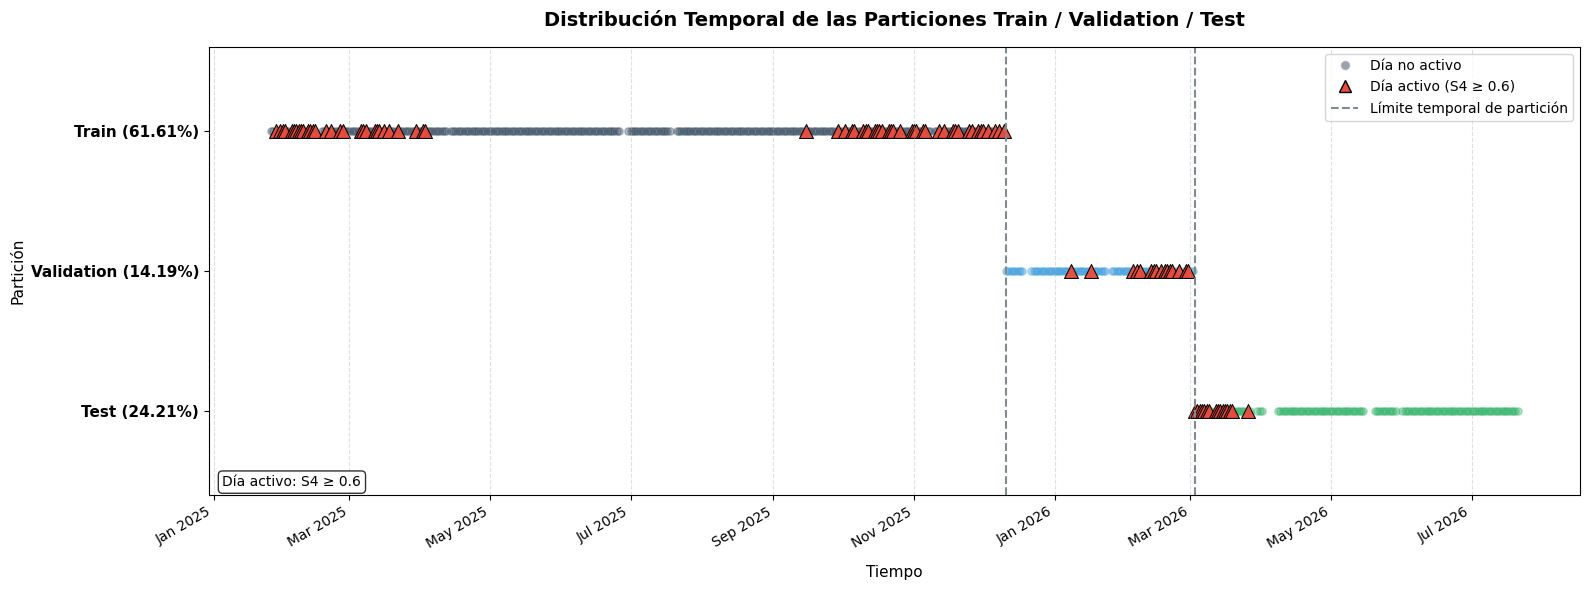

In [28]:
mapa_temporal = visualizar_distribucion_temporal_train_val_test(
    train_df,
    val_df,
    test_df,
    umbral_s4=S4_EVENT_THRESHOLD
)

In [25]:
# =============================================================================
# 10. FEATURE ENGINEERING TEMPORAL
# =============================================================================

def add_temporal_features(df):
    """Agrega periodicidad diaria y anual mediante seno/coseno."""

    out = df.copy()
    idx = pd.DatetimeIndex(out.index)

    minute_of_day = idx.hour * 60 + idx.minute
    daily_period = 24 * 60

    out["daily_sin"] = np.sin(2 * np.pi * minute_of_day / daily_period)
    out["daily_cos"] = np.cos(2 * np.pi * minute_of_day / daily_period)

    # El denominador usa el número de días del año correspondiente.
    day_of_year = idx.dayofyear
    days_in_year = np.where(idx.is_leap_year, 366, 365)

    out["day_of_year_sin"] = np.sin(2 * np.pi * (day_of_year - 1) / days_in_year)
    out["day_of_year_cos"] = np.cos(2 * np.pi * (day_of_year - 1) / days_in_year)

    return out


# Las transformaciones son deterministas respecto al timestamp.
# No aprenden parámetros del futuro y por ello no requieren fit.
train_fe = add_temporal_features(train_df)
val_fe = add_temporal_features(val_df)
test_fe = add_temporal_features(test_df)

missing_features = [c for c in FEATURES_COLS if c not in train_fe.columns]
if missing_features:
    raise ValueError(f"Faltan variables requeridas por FEATURES_COLS: {missing_features}"s)

print("Features temporales agregadas.")
print(FEATURES_COLS)


Features temporales agregadas.
['TEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'AE_Index', 'f10.7_Index', 'daily_sin', 'daily_cos', 'day_of_year_sin', 'day_of_year_cos', 'S4']


In [26]:
# =============================================================================
# 11. ESCALAMIENTO: FIT EXCLUSIVO EN TRAIN
# =============================================================================

def create_scaler(scaler_type=SCALER_TYPE):
    if scaler_type.lower() == "minmax":
        return MinMaxScaler(feature_range=(0, 1))
    if scaler_type.lower() == "standard":
        return StandardScaler()
    raise ValueError("SCALER_TYPE debe ser 'minmax' o 'standard'.")


def scale_partitions(
    train_df,
    val_df,
    test_df,
    features_cols,
    scaler_type=SCALER_TYPE,
):
    scaler = create_scaler(scaler_type)

    train_values = train_df[features_cols].astype(float)
    val_values = val_df[features_cols].astype(float)
    test_values = test_df[features_cols].astype(float)

    # CRÍTICO: FIT SOLO EN TRAIN.
    scaler.fit(train_values)

    train_scaled = pd.DataFrame(
        scaler.transform(train_values),
        index=train_df.index,
        columns=features_cols,
    )

    val_scaled = pd.DataFrame(
        scaler.transform(val_values),
        index=val_df.index,
        columns=features_cols,
    )

    test_scaled = pd.DataFrame(
        scaler.transform(test_values),
        index=test_df.index,
        columns=features_cols,
    )

    return train_scaled, val_scaled, test_scaled, scaler


train_scaled, val_scaled, test_scaled, scaler = scale_partitions(train_fe,val_fe,test_fe,FEATURES_COLS,)

print("\nScaler:", scaler.__class__.__name__)
print("✓ FIT realizado exclusivamente con TRAIN.")
print("✓ Validation transformado sin FIT.")
print("✓ Test transformado sin FIT.")



Scaler: MinMaxScaler
✓ FIT realizado exclusivamente con TRAIN.
✓ Validation transformado sin FIT.
✓ Test transformado sin FIT.


In [29]:
train_scaled

,TEC,ROTI,Kp_Index,Dst_Index,AE_Index,f10.7_Index,daily_sin,daily_cos,day_of_year_sin,day_of_year_cos,S4
Tiempo,,,,,,,,,,,
2025-01-26 00:35:00,0.447903,0.720329,0.034483,0.783939,0.007605,0.249403,0.576062,0.994185,0.708599,0.989465,0.088617
2025-01-26 00:36:00,0.448517,0.720526,0.034483,0.784000,0.007560,0.249403,0.578217,0.993849,0.708599,0.989465,0.060519
2025-01-26 00:37:00,0.449130,0.720724,0.034483,0.784061,0.007515,0.249403,0.580371,0.993503,0.708599,0.989465,0.064841
2025-01-26 00:38:00,0.449743,0.720855,0.034483,0.784121,0.007470,0.249403,0.582524,0.993148,0.708599,0.989465,0.048991
2025-01-26 00:39:00,0.450357,0.721053,0.034483,0.784182,0.007425,0.249403,0.584675,0.992783,0.708599,0.989465,0.046830
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-10 23:41:00,0.452793,0.087303,0.689655,0.579212,0.424359,0.171285,0.458596,0.998288,0.315136,1.000000,0.026657
2025-12-10 23:42:00,0.453660,0.087237,0.689655,0.577818,0.422631,0.169613,0.460770,0.998463,0.315136,1.000000,0.030259
2025-12-10 23:43:00,0.454526,0.087237,0.689655,0.576424,0.420903,0.167941,0.462946,0.998630,0.315136,1.000000,0.035303


## **II. ETAPA II**

1. Preparación de datos- Generador de ventanas previo al LSTM
2. Generador de tensores dinamicos para Entrenamiento, Validacion y Testeo.
3. DEfinicion del Modelo y Función de perdida
4. Evaluación, desnormalizar y evaluar
5. Motor del Grid Search Optimizado
6. Ejecución del Pipeline(main)

In [48]:
# =============================================================================
# 12. GENERACIÓN DE VENTANAS TEMPORALES PARA LSTM MULTISTEP
# =============================================================================

def create_lstm_sequences(
    data_scaled,
    feature_columns,
    target_column="S4",
    lookback=70,
    horizon=10,
    sampling_minutes=1,
    return_metadata=True,
):
    """
    Genera ventanas temporales para un modelo LSTM multistep.

    Definición de cada muestra:

        X(t) = [t-(lookback-1), ..., t]
        Y(t) = [t+1, ..., t+horizon]

    Ejemplo con:

        lookback = 70
        horizon  = 10

    entonces:

        X = 70 observaciones
        Y = 10 observaciones futuras

    La función:

    1. Verifica la estructura temporal.
    2. Verifica que existan las variables requeridas.
    3. Detecta gaps de datos.
    4. No genera ventanas que atraviesen gaps.
    5. Devuelve tensores compatibles con Keras.
    6. Opcionalmente devuelve metadatos temporales de cada ventana.

    IMPORTANTE
    ----------
    Esta función debe ejecutarse por separado sobre:

        train_scaled
        val_scaled
        test_scaled

    para evitar que una ventana atraviese los límites entre particiones.
    """

    # =========================================================================
    # 1. VALIDACIONES BÁSICAS
    # =========================================================================

    if not isinstance(data_scaled, pd.DataFrame):
        raise TypeError(
            "data_scaled debe ser un pandas.DataFrame."
        )

    if data_scaled.empty:
        raise ValueError(
            "data_scaled está vacío."
        )

    if not isinstance(
        data_scaled.index,
        pd.DatetimeIndex
    ):
        raise TypeError(
            "El índice de data_scaled debe ser DatetimeIndex."
        )

    if not data_scaled.index.is_monotonic_increasing:
        raise ValueError(
            "El índice temporal debe estar ordenado "
            "cronológicamente."
        )

    if data_scaled.index.has_duplicates:
        raise ValueError(
            "El índice temporal contiene timestamps duplicados."
        )

    if target_column not in data_scaled.columns:
        raise ValueError(
            f"No existe la variable objetivo "
            f"'{target_column}'."
        )

    missing_features = [
        column
        for column in feature_columns
        if column not in data_scaled.columns
    ]

    if missing_features:
        raise ValueError(
            "Faltan las siguientes variables de entrada: "
            f"{missing_features}"
        )

    if lookback < 1:
        raise ValueError(
            "lookback debe ser >= 1."
        )

    if horizon < 1:
        raise ValueError(
            "horizon debe ser >= 1."
        )

    if sampling_minutes <= 0:
        raise ValueError(
            "sampling_minutes debe ser > 0."
        )

    # =========================================================================
    # 2. NÚMERO DE OBSERVACIONES
    # =========================================================================

    number_of_rows = len(data_scaled)

    # Para construir una ventana necesitamos:
    #
    #   lookback observaciones de entrada
    #   +
    #   horizon observaciones futuras
    #
    minimum_required_rows = (
        lookback + horizon
    )

    if number_of_rows < minimum_required_rows:
        empty_X = np.empty(
            (
                0,
                lookback,
                len(feature_columns),
            ),
            dtype=np.float32,
        )

        empty_y = np.empty(
            (
                0,
                horizon,
            ),
            dtype=np.float32,
        )

        if return_metadata:

            empty_metadata = pd.DataFrame(
                columns=[
                    "X_start",
                    "X_end",
                    "y_start",
                    "y_end",
                ]
            )

            return (
                empty_X,
                empty_y,
                empty_metadata,
            )

        return empty_X, empty_y

    # =========================================================================
    # 3. EXTRAER DATOS NUMÉRICOS
    # =========================================================================

    input_values = (
        data_scaled[
            feature_columns
        ]
        .to_numpy(
            dtype=np.float32
        )
    )

    target_values = (
        data_scaled[
            target_column
        ]
        .to_numpy(
            dtype=np.float32
        )
    )

    # =========================================================================
    # 4. TIMESTAMPS
    # =========================================================================

    timestamps = (
        data_scaled.index
    )

    # Convertimos los timestamps a nanosegundos.
    #
    # Esto permite detectar gaps utilizando operaciones numéricas
    # mucho más eficientes que construir un pandas.Series para cada ventana.

    timestamp_ns = (
        timestamps
        .asi8
    )

    expected_interval_ns = (
        sampling_minutes
        * 60
        * 1_000_000_000
    )

    # =========================================================================
    # 5. DETECTAR GAPS
    # =========================================================================

    # Diferencia temporal entre observaciones consecutivas.

    timestamp_differences = (
        np.diff(
            timestamp_ns
        )
    )

    # True si existe un intervalo diferente al esperado.

    invalid_intervals = (
        timestamp_differences
        != expected_interval_ns
    )

    # -------------------------------------------------------------------------
    # Acumulado de gaps
    # -------------------------------------------------------------------------
    #
    # Esto permite preguntar rápidamente si una ventana contiene un gap,
    # sin volver a calcular np.diff() para cada ventana.
    #
    # Ejemplo:
    #
    # gap_count_prefix[k]
    #
    # contiene cuántos gaps existen antes de la posición k.

    gap_count_prefix = np.concatenate(
        [
            np.array(
                [0],
                dtype=np.int64
            ),
            np.cumsum(
                invalid_intervals,
                dtype=np.int64
            ),
        ]
    )

    # =========================================================================
    # 6. CREAR VENTANAS
    # =========================================================================

    X_sequences = []
    y_sequences = []

    metadata = []

    # -------------------------------------------------------------------------
    # El índice "forecast_end" representa el último timestamp disponible
    # dentro de X.
    #
    # Por ejemplo:
    #
    # LOOKBACK = 70
    #
    # X:
    #
    # [t-69, ..., t]
    #
    # Y:
    #
    # [t+1, ..., t+horizon]
    # -------------------------------------------------------------------------

    first_forecast_end = (
        lookback - 1
    )

    last_forecast_end = (
        number_of_rows
        - horizon
        - 1
    )

    for forecast_end in range(
        first_forecast_end,
        last_forecast_end + 1,
    ):

        # ---------------------------------------------------------------------
        # Inicio de X
        # ---------------------------------------------------------------------

        input_start = (
            forecast_end
            - lookback
            + 1
        )

        # ---------------------------------------------------------------------
        # Fin de Y
        # ---------------------------------------------------------------------

        target_end = (
            forecast_end
            + horizon
        )

        # ---------------------------------------------------------------------
        # Verificar continuidad temporal
        # ---------------------------------------------------------------------
        #
        # Toda la región:
        #
        # X + Y
        #
        # debe ser estrictamente continua.
        #
        # Si existe al menos un gap, descartamos la ventana.

        number_of_gaps = (
            gap_count_prefix[
                target_end
            ]
            -
            gap_count_prefix[
                input_start
            ]
        )

        if number_of_gaps != 0:
            continue

        # ---------------------------------------------------------------------
        # Crear X
        # ---------------------------------------------------------------------

        input_window = (
            input_values[
                input_start:
                forecast_end + 1
            ]
        )

        # ---------------------------------------------------------------------
        # Crear Y
        # ---------------------------------------------------------------------

        target_window = (
            target_values[
                forecast_end + 1:
                target_end + 1
            ]
        )

        # ---------------------------------------------------------------------
        # Agregar secuencia
        # ---------------------------------------------------------------------

        X_sequences.append(
            input_window
        )

        y_sequences.append(
            target_window
        )

        # ---------------------------------------------------------------------
        # Guardar información temporal
        # ---------------------------------------------------------------------

        if return_metadata:

            metadata.append(
                {
                    "X_start":
                        timestamps[
                            input_start
                        ],

                    "X_end":
                        timestamps[
                            forecast_end
                        ],

                    "y_start":
                        timestamps[
                            forecast_end + 1
                        ],

                    "y_end":
                        timestamps[
                            target_end
                        ],
                }
            )

    # =========================================================================
    # 7. CONVERTIR A TENSORES NUMPY
    # =========================================================================

    if X_sequences:

        X = np.stack(
            X_sequences
        ).astype(
            np.float32
        )

        y = np.stack(
            y_sequences
        ).astype(
            np.float32
        )

    else:

        X = np.empty(
            (
                0,
                lookback,
                len(feature_columns),
            ),
            dtype=np.float32,
        )

        y = np.empty(
            (
                0,
                horizon,
            ),
            dtype=np.float32,
        )

    # =========================================================================
    # 8. METADATOS
    # =========================================================================

    if return_metadata:

        metadata_df = pd.DataFrame(
            metadata
        )

        return (
            X,
            y,
            metadata_df,
        )

    return X, y


# =============================================================================
# 12.1 GENERACIÓN PARA TRAIN / VALIDATION / TEST
# =============================================================================

def generate_lstm_datasets(
    train_scaled,
    val_scaled,
    test_scaled,
    feature_columns,
    target_column="S4",
    lookback=70,
    horizon=10,
    sampling_minutes=1,
):
    """
    Genera las ventanas LSTM de Train, Validation y Test.

    La generación se realiza independientemente para cada partición.

    Esto garantiza que:

        Train     no utilice datos de Validation.
        Validation no utilice datos de Test.
        Test       no utilice datos externos.

    Retorna:

        X_train
        y_train
        meta_train

        X_val
        y_val
        meta_val

        X_test
        y_test
        meta_test
    """

    print()
    print("=" * 80)
    print("GENERACIÓN DE VENTANAS LSTM")
    print("=" * 80)

    print(
        f"LOOKBACK:             {lookback} minutos"
    )

    print(
        f"HORIZON:              {horizon} minutos"
    )

    print(
        f"Cadencia esperada:    {sampling_minutes} minuto(s)"
    )

    print(
        f"Número de features:   {len(feature_columns)}"
    )

    print(
        f"Variable objetivo:    {target_column}"
    )

    # =========================================================================
    # TRAIN
    # =========================================================================

    X_train, y_train, meta_train = create_lstm_sequences(
        data_scaled=train_scaled,
        feature_columns=feature_columns,
        target_column=target_column,
        lookback=lookback,
        horizon=horizon,
        sampling_minutes=sampling_minutes,
        return_metadata=True,
    )

    # =========================================================================
    # VALIDATION
    # =========================================================================

    X_val, y_val, meta_val = create_lstm_sequences(
        data_scaled=val_scaled,
        feature_columns=feature_columns,
        target_column=target_column,
        lookback=lookback,
        horizon=horizon,
        sampling_minutes=sampling_minutes,
        return_metadata=True,
    )

    # =========================================================================
    # TEST
    # =========================================================================

    X_test, y_test, meta_test = create_lstm_sequences(
        data_scaled=test_scaled,
        feature_columns=feature_columns,
        target_column=target_column,
        lookback=lookback,
        horizon=horizon,
        sampling_minutes=sampling_minutes,
        return_metadata=True,
    )

    # =========================================================================
    # REPORTE
    # =========================================================================

    print()
    print("-" * 80)

    print(
        f"TRAIN:"
    )

    print(
        f"   X_train = {X_train.shape}"
    )

    print(
        f"   y_train = {y_train.shape}"
    )

    print(
        f"   ventanas = {len(X_train):,}"
    )

    print()

    print(
        f"VALIDATION:"
    )

    print(
        f"   X_val = {X_val.shape}"
    )

    print(
        f"   y_val = {y_val.shape}"
    )

    print(
        f"   ventanas = {len(X_val):,}"
    )

    print()

    print(
        f"TEST:"
    )

    print(
        f"   X_test = {X_test.shape}"
    )

    print(
        f"   y_test = {y_test.shape}"
    )

    print(
        f"   ventanas = {len(X_test):,}"
    )

    print("-" * 80)

    return (
        X_train,
        y_train,
        meta_train,
        X_val,
        y_val,
        meta_val,
        X_test,
        y_test,
        meta_test,
    )


# =============================================================================
# 12.2 EJECUCIÓN
# =============================================================================

(
    X_train,
    y_train,
    meta_train,
    X_val,
    y_val,
    meta_val,
    X_test,
    y_test,
    meta_test,
) = generate_lstm_datasets(
    train_scaled=train_scaled,
    val_scaled=val_scaled,
    test_scaled=test_scaled,
    feature_columns=FEATURES_COLS,
    target_column=TARGET_COL,
    lookback=LOOKBACK,
    horizon=HORIZON,
    sampling_minutes=SAMPLING_MINUTES,
)


GENERACIÓN DE VENTANAS LSTM
LOOKBACK:             70 minutos
HORIZON:              10 minutos
Cadencia esperada:    1 minuto(s)
Número de features:   11
Variable objetivo:    S4

--------------------------------------------------------------------------------
TRAIN:
   X_train = (402603, 70, 11)
   y_train = (402603, 10)
   ventanas = 402,603

VALIDATION:
   X_val = (92099, 70, 11)
   y_val = (92099, 10)
   ventanas = 92,099

TEST:
   X_test = (158159, 70, 11)
   y_test = (158159, 10)
   ventanas = 158,159
--------------------------------------------------------------------------------


In [49]:
# =============================================================================
# 13. VALIDACIÓN DE VENTANAS
# =============================================================================

def validate_sequences(X, y, meta, lookback, horizon, name):
    if X.ndim != 3:
        raise AssertionError(f"{name}: X debe ser 3D.")
    if y.ndim != 2:
        raise AssertionError(f"{name}: y debe ser 2D.")

    if X.shape[0] != y.shape[0] or X.shape[0] != len(meta):
        raise AssertionError(f"{name}: número de muestras inconsistente.")

    if X.shape[1] != lookback:
        raise AssertionError(f"{name}: lookback incorrecto.")

    if y.shape[1] != horizon:
        raise AssertionError(f"{name}: horizon incorrecto.")

    if len(meta):
        if not (meta["X_end"] < meta["y_start"]).all():
            raise AssertionError(
                f"{name}: existe solapamiento entre X y Y."
            )

    print(
        f"✓ {name}: {X.shape[0]:,} ventanas válidas | "
        f"X={X.shape} | y={y.shape}"
    )


validate_sequences(X_train, y_train, meta_train, LOOKBACK, HORIZON, "TRAIN")
validate_sequences(X_val, y_val, meta_val, LOOKBACK, HORIZON, "VALIDATION")
validate_sequences(X_test, y_test, meta_test, LOOKBACK, HORIZON, "TEST")


def validate_no_cross_partition_windows(meta_train, meta_val, meta_test):
    """Verifica que las ventanas no atraviesen los límites."""

    if len(meta_train) and len(meta_val):
        if meta_train["y_end"].max() >= meta_val["X_start"].min():
            raise AssertionError("Posible solapamiento temporal Train/Validation.")

    if len(meta_val) and len(meta_test):
        if meta_val["y_end"].max() >= meta_test["X_start"].min():
            raise AssertionError("Posible solapamiento temporal Validation/Test.")

    print("✓ No existen ventanas cruzando límites de partición.")


validate_no_cross_partition_windows(
    meta_train, meta_val, meta_test
)


✓ TRAIN: 402,603 ventanas válidas | X=(402603, 70, 11) | y=(402603, 10)
✓ VALIDATION: 92,099 ventanas válidas | X=(92099, 70, 11) | y=(92099, 10)
✓ TEST: 158,159 ventanas válidas | X=(158159, 70, 11) | y=(158159, 10)
✓ No existen ventanas cruzando límites de partición.


In [50]:
# =============================================================================
# 14. REPORTE FINAL DE TRAIN / VALIDATION / TEST
# =============================================================================

def partition_report(
    train_df,
    val_df,
    test_df,
    events_df,
    threshold=S4_EVENT_THRESHOLD,
):
    rows = []

    for name, part in [
        ("TRAIN", train_df),
        ("VALIDATION", val_df),
        ("TEST", test_df),
    ]:
        if part.empty:
            rows.append({
                "partition": name,
                "start": pd.NaT,
                "end": pd.NaT,
                "days": 0,
                "active_days": 0,
                "inactive_days": 0,
                "active_pct": 0.0,
                "events": 0,
                "observations": 0,
                "event_duration_min": 0.0,
            })
            continue

        day_max = part.groupby(part.index.normalize())[TARGET_COL].max()
        active = day_max >= threshold

        start = part.index.min()
        end = part.index.max()

        ev = events_df[
            (events_df["start"] >= start) &
            (events_df["end"] <= end)
        ] if not events_df.empty else events_df

        rows.append({
            "partition": name,
            "start": start,
            "end": end,
            "days": len(day_max),
            "active_days": int(active.sum()),
            "inactive_days": int((~active).sum()),
            "active_pct": 100 * active.mean(),
            "events": len(ev),
            "observations": len(part),
            "event_duration_min": (
                float(ev["duration_min"].sum()) if len(ev) else 0.0
            ),
        })

    report = pd.DataFrame(rows)
    report["inactive_pct"] = 100 - report["active_pct"]

    return report


partition_summary = partition_report(
    train_df,
    val_df,
    test_df,
    events_df,
)

display(partition_summary)


,partition,start,end,days,active_days,inactive_days,active_pct,events,observations,event_duration_min,inactive_pct
0,TRAIN,2025-01-26 00:35:00,2025-12-10 23:45:00,310,65,245,20.967742,354,428831,652.0,79.032258
1,VALIDATION,2025-12-11 00:01:00,2026-03-02 23:45:00,76,16,60,21.052632,116,98748,246.0,78.947368
2,TEST,2026-03-03 00:01:00,2026-07-21 22:45:00,126,16,110,12.698413,251,168511,491.0,87.301587


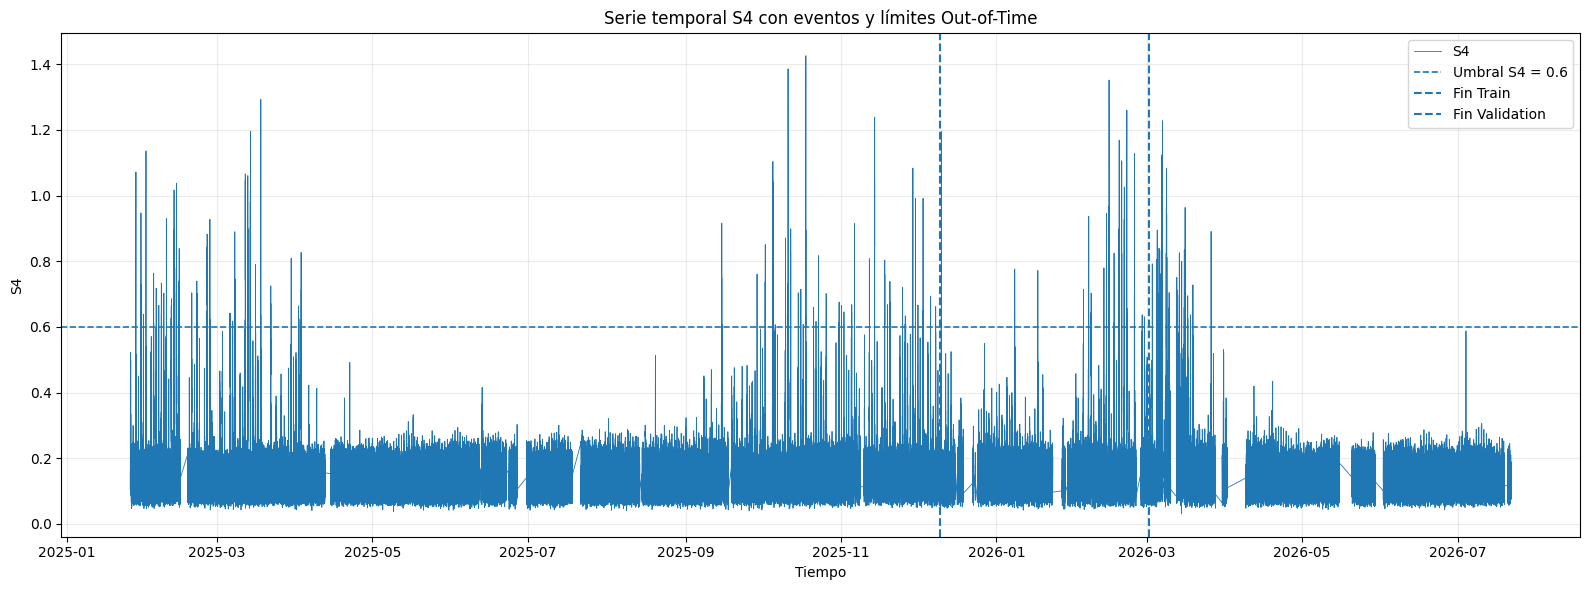

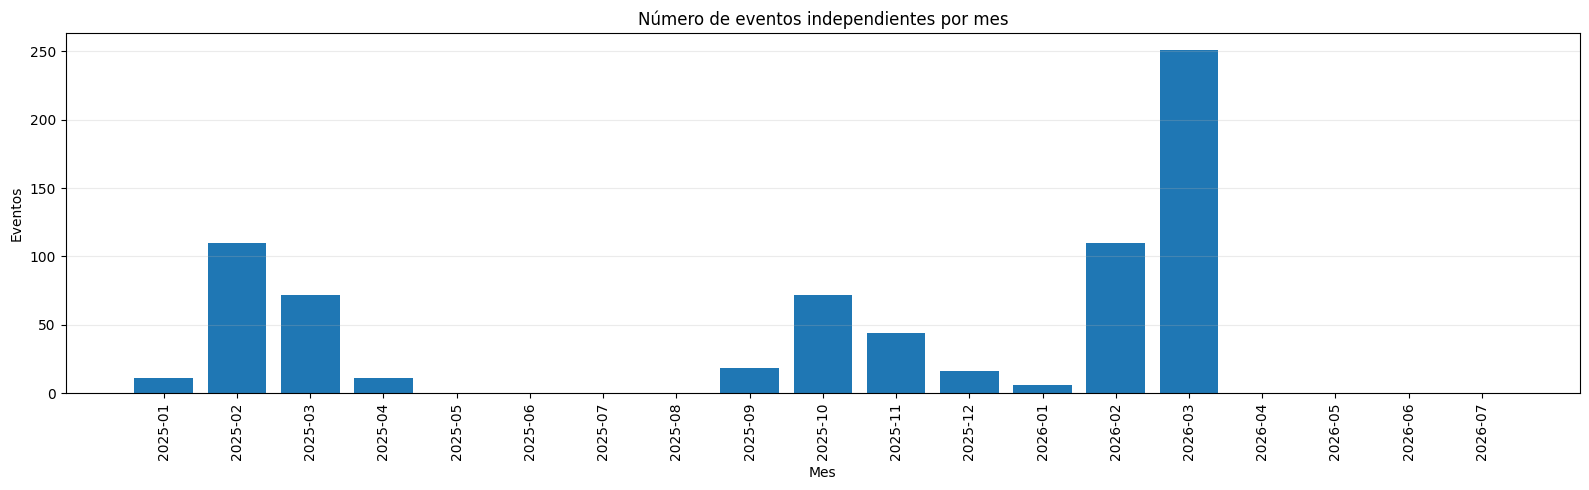

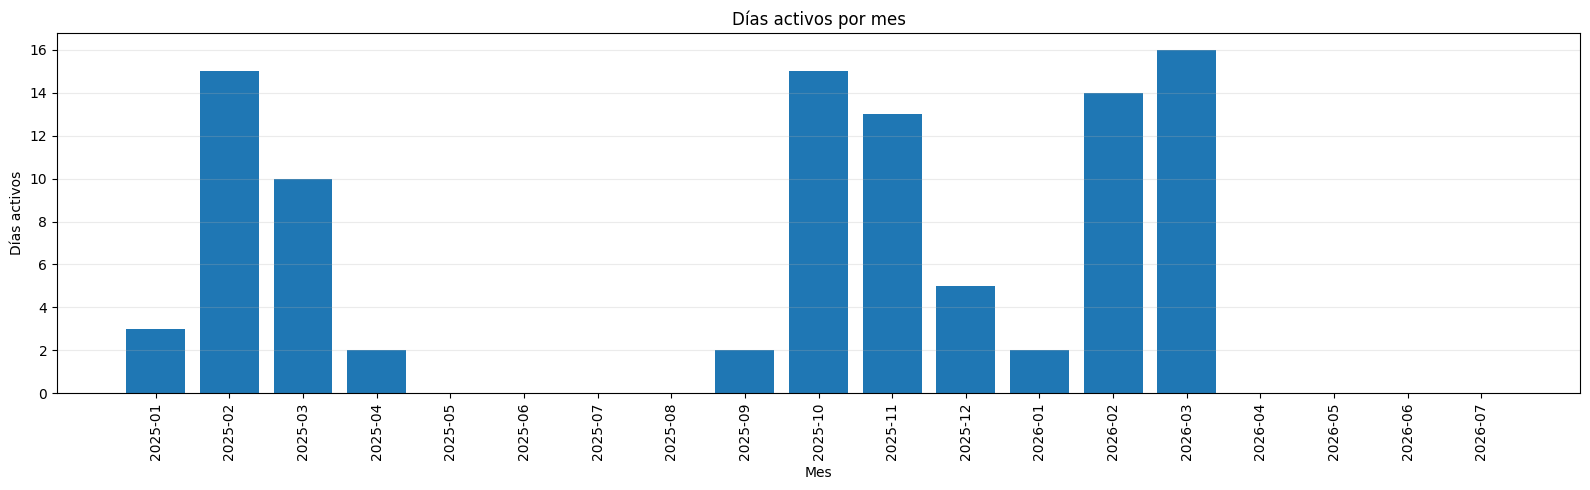

In [51]:
# =============================================================================
# 15. VISUALIZACIONES
# =============================================================================

def plot_s4_with_splits(df, events_df, split_info, threshold=S4_EVENT_THRESHOLD):
    fig, ax = plt.subplots(figsize=(16, 6))

    ax.plot(
        df.index,
        df[TARGET_COL],
        linewidth=0.6,
        label="S4",
    )

    ax.axhline(
        threshold,
        linestyle="--",
        linewidth=1.2,
        label=f"Umbral S4 = {threshold}",
    )

    train_end = pd.Timestamp(split_info["train_end"])
    val_end = pd.Timestamp(split_info["val_end"])

    ax.axvline(train_end, linestyle="--", linewidth=1.5, label="Fin Train")
    ax.axvline(val_end, linestyle="--", linewidth=1.5, label="Fin Validation")

    if events_df is not None and not events_df.empty:
        for _, ev in events_df.iterrows():
            ax.axvspan(
                ev["start"],
                ev["end"],
                alpha=0.15,
            )

    ax.set_title("Serie temporal S4 con eventos y límites Out-of-Time")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("S4")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_monthly_events(monthly_summary):
    labels = monthly_summary["month"].astype(str)

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.bar(
        labels,
        monthly_summary["independent_events"],
    )
    ax.set_title("Número de eventos independientes por mes")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Eventos")
    ax.tick_params(axis="x", rotation=90)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_active_days(monthly_summary):
    labels = monthly_summary["month"].astype(str)

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.bar(
        labels,
        monthly_summary["active_days"],
    )
    ax.set_title("Días activos por mes")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Días activos")
    ax.tick_params(axis="x", rotation=90)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


plot_s4_with_splits(df, events_df, split_info)
plot_monthly_events(monthly_summary)
plot_active_days(monthly_summary)


## Interpretación metodológica

### Si Validation tiene pocos eventos
No se debe redistribuir aleatoriamente. Primero se revisa si existe otro corte cronológico razonable. Si no existe, se conserva el corte temporal y se reporta la baja cantidad de eventos. Las métricas sobre eventos deben interpretarse con intervalos de incertidumbre y junto con métricas globales.

### Si Test tiene pocos eventos
No se modifica artificialmente el Test. Un Test pequeño en eventos puede ser una limitación real del fenómeno y debe quedar documentada.

### Si existe un mes completo sin eventos
Se mantiene. Es información científica sobre períodos de baja/no actividad y evita que el modelo aprenda únicamente situaciones activas.

### Si los eventos están concentrados en determinados meses
Esto debe aparecer en `monthly_summary` y en la discusión de representatividad. No se redistribuyen los eventos.

### Si Train/Validation/Test tienen proporciones diferentes
La prioridad es causalidad temporal, no igualdad artificial. La tabla `partition_summary` permite reportar la diferencia.

### Si existen gaps
No se rellenan automáticamente y no se generan ventanas que los atraviesen. Primero debe determinarse si el gap representa ausencia real de observación o un problema de adquisición/preprocesamiento.

### Si existen días incompletos
Se conservan, pero se reportan mediante `quality_report["daily_quality"]`. No se asume que cada día tenga exactamente 1440 observaciones.

### Si existen eventos muy largos
Se contabilizan como un evento independiente con su duración total. No se cuentan como cientos de eventos.

### Si existen muchos minutos con S4 >= 0.6
Eso no significa automáticamente que existan muchos eventos. La tabla distingue `event_observations` de `independent_events`.

### Prioridad metodológica

**INTEGRIDAD TEMPORAL > AUSENCIA DE DATA LEAKAGE > REPRESENTATIVIDAD > BALANCE PERFECTO**

El resultado final queda disponible en:

- `monthly_summary`
- `daily_status`
- `quality_report`
- `partition_summary`
- `events_df`
- `X_train`, `y_train`
- `X_val`, `y_val`
- `X_test`, `y_test`

Para un modelo LSTM multistep, `y_train`, `y_val` y `y_test` contienen respectivamente los siguientes `HORIZON` valores de S4, mientras que cada `X` contiene los `LOOKBACK` minutos anteriores.


## Nota específica respecto al notebook original

La versión original presentaba una fuga metodológica importante: utilizaba una función denominada `dividir_estratificado_por_dias()` que aplicaba `train_test_split()` sobre días activos y quietos y posteriormente limitaba los días quietos a la cantidad de días activos. Eso alteraba la distribución natural de días y rompía la naturaleza Out-of-Time del problema. fileciteturn5file0L153-L212

Además, el análisis original contabilizaba actividad diaria con `S4 > 0.6`, mientras que esta versión utiliza el criterio configurable `S4 >= S4_EVENT_THRESHOLD`, tal como establece el prompt metodológico. fileciteturn4file0L22-L50

El notebook original también utilizaba solamente `Hora_Sin` y `Hora_Cos`; esta versión añade la representación cíclica anual mediante `day_of_year_sin` y `day_of_year_cos`, manteniendo el timestamp como referencia para la partición. fileciteturn4file0L79-L106


## **3. Antes de entrenar nuevamente: auditoría completa del pipeline**
## **Debemos responder:**

- A. ¿Dónde se hace la interpolación? 
- B. ¿Dónde se normalizan los datos?
- C. ¿Con qué datos se calcula el scaler?
- D. ¿Cuándo se crean las ventanas temporales?
- E. ¿Cuándo se realiza el split?
- F. ¿Se utilizó información futura para calcular algún parámetro?
- G. ¿El test fue utilizado directa o indirectamente durante el entrenamiento?

Hay que demostrar que todo el pipeline es temporalmente correcto

## **4. Después: reconstruir el experimento**

Una vez solucionado el leakage, debemos volver a ejecutar los modelos.

Aquí comienza realmente el núcleo de la subsanación.

Yo plantearía esta estructura experimental:

### **Experimento 1 — Baseline de persistencia**
S4(t+10) = S4(t)

Es el modelo ingenuo solicitado por Marcos.

Esto nos da una referencia:

"¿Realmente mi Deep Learning es mejor que simplemente asumir que el próximo valor será igual al actual?"

El objetivo del Experimento 1 es precisamente tener una referencia independiente del modelo de Deep Learning.

EL  asesor está planteando:
```text
 S^4(t+10)=S4(t)
```

Es decir: “para los próximos 10 minutos, asumo que el S4 será igual al último S4 observado”.

Para tu caso, como estás haciendo pronóstico multistep, hay dos formas de definirlo. Vamos a dejar ambas claramente diferenciadas.

# **1. Baseline de persistencia para tu experimento**

Si tu horizonte es de 10 minutos:

                OBSERVACIÓN
                    │
                    ▼
              S4(t) = 0.42
                    │
                    │ persistencia
                    ▼
     ┌──────┬──────┬──────┬──────┐
    t+1    t+2    t+3    ...    t+10
    0.42   0.42   0.42   ...    0.42

Matemáticamente:

S^4(t+h)=S4(t),     h=1,…,H

Por tanto, para HORIZON = 10:

y_pred = [
    S4(t),
    S4(t),
    S4(t),
    ...
    S4(t)
]

Esto es exactamente lo que deberías comparar contra:

**Persistencia VS LSTM**

# **2. Lo importante: usar exactamente las mismas muestras de TEST**

Esto es fundamental.

Tu LSTM actualmente genera:

X_test

y_test

Con

70 minutos → 10 minutos

El baseline debe utilizar exactamente esos mismos y_test.

No debemos crear otro conjunto de prueba.

La comparación debe ser:

                  MISMO TEST
                     │
            ┌────────┴────────┐
            │                 │
            ▼                 ▼
       Persistencia          LSTM
            │                 │
            ▼                 ▼
       predicciones       predicciones
            │                 │
            └────────┬────────┘
                     ▼
                MISMAS MÉTRICAS

Esto hace que la comparación sea justa.

# **4. Implementación recomendada**

Suponiendo que ya tienes:

In [56]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error


def baseline_persistencia(
    X_test,
    y_test,
    scaler,
    features_cols,
    umbral_real=0.6
):
    """
    Baseline de persistencia para pronóstico multistep.

    Para cada muestra:
        S4_pred(t+h) = S4(t)

    donde S4(t) corresponde al último valor observado
    en la ventana de entrada.

    Parameters
    ----------
    X_test : np.ndarray
        Tensor de entrada:
        (n_samples, lookback, n_features)

    y_test : np.ndarray
        Valores reales futuros:
        (n_samples, horizon)

    scaler : MinMaxScaler
        Scaler ajustado exclusivamente con TRAIN.

    features_cols : list
        Lista de variables utilizadas como features.

    umbral_real : float
        Umbral físico para identificar eventos.

    Returns
    -------
    dict
        Métricas del baseline.
    """

    # ---------------------------------------------------------
    # 1. Obtener índice de S4
    # ---------------------------------------------------------
    idx_s4 = features_cols.index("S4")

    # ---------------------------------------------------------
    # 2. Último S4 observado en cada ventana
    # ---------------------------------------------------------
    #
    # X_test:
    #
    # [muestras, tiempo, variables]
    #
    # Tomamos:
    #
    # X_test[:, -1, idx_s4]
    #
    # que corresponde a S4(t)
    #
    s4_last_scaled = X_test[:, -1, idx_s4]

    # ---------------------------------------------------------
    # 3. Recuperar escala física de S4
    # ---------------------------------------------------------
    min_s4 = scaler.data_min_[idx_s4]
    max_s4 = scaler.data_max_[idx_s4]

    range_s4 = max_s4 - min_s4

    # Último S4 observado en escala real
    s4_last_real = (
        s4_last_scaled * range_s4
    ) + min_s4

    # ---------------------------------------------------------
    # 4. Desnormalizar valores reales
    # ---------------------------------------------------------
    y_test_real = (
        y_test * range_s4
    ) + min_s4

    # ---------------------------------------------------------
    # 5. Crear predicción persistente
    # ---------------------------------------------------------
    #
    # Si HORIZON = 10:
    #
    # [S4(t), S4(t), ..., S4(t)]
    #
    horizon = y_test.shape[1]

    y_pred_real = np.repeat(
        s4_last_real[:, np.newaxis],
        horizon,
        axis=1
    )

    # ---------------------------------------------------------
    # 6. Aplanar para métricas globales
    # ---------------------------------------------------------
    flat_true = y_test_real.flatten()
    flat_pred = y_pred_real.flatten()

    # ---------------------------------------------------------
    # 7. Métricas globales
    # ---------------------------------------------------------
    rmse_global = np.sqrt(
        mean_squared_error(
            flat_true,
            flat_pred
        )
    )

    mae_global = mean_absolute_error(
        flat_true,
        flat_pred
    )

    # ---------------------------------------------------------
    # 8. Métricas sobre eventos
    # ---------------------------------------------------------
    mask_evento = flat_true >= umbral_real

    if np.sum(mask_evento) > 0:

        rmse_evento = np.sqrt(
            mean_squared_error(
                flat_true[mask_evento],
                flat_pred[mask_evento]
            )
        )

        mae_evento = mean_absolute_error(
            flat_true[mask_evento],
            flat_pred[mask_evento]
        )

    else:

        rmse_evento = np.nan
        mae_evento = np.nan

    # ---------------------------------------------------------
    # 9. Resultado
    # ---------------------------------------------------------
    resultados = {
        "Modelo": "Persistencia",
        "RMSE_Global": rmse_global,
        "MAE_Global": mae_global,
        "RMSE_Evento": rmse_evento,
        "MAE_Evento": mae_evento,
        "N_muestras": len(X_test),
        "Horizonte": horizon
    }

    return resultados, y_pred_real, y_test_real

# **5. Cómo ejecutarlo en tu caso**

Como tú tienes:

In [54]:
LOOKBACK = 70
HORIZON = 10

In [57]:
resultados_persistencia, y_pred_persistencia, y_test_real = baseline_persistencia(
    X_test=X_test,
    y_test=y_test,
    scaler=scaler,
    features_cols=FEATURES_COLS,
    umbral_real=0.6
)

print("\n" + "="*60)
print("BASELINE DE PERSISTENCIA")
print("="*60)

for clave, valor in resultados_persistencia.items():
    print(f"{clave}: {valor}")


BASELINE DE PERSISTENCIA
Modelo: Persistencia
RMSE_Global: 0.048190961739048695
MAE_Global: 0.03054176307310366
RMSE_Evento: 0.29254138566936283
MAE_Evento: 0.23601308885121264
N_muestras: 158159
Horizonte: 10
